H is the same
H is the same
Transmon anharmonicity: -0.28 GHz
Transmon $\omega_{01}$: 3.3409903381196786 GHz
H is different
Fluxonium anharmonicity: 3.24 GHz
Fluxonium $\omega_{01}$: 0.4452510793213489 GHz


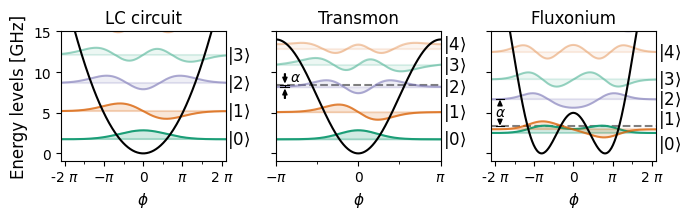

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite
from math import factorial

# Parameters
phi_max = 10 * np.pi  # phase basis cutoff
N = 1000  # number of grid points
phi = np.linspace(-phi_max, phi_max, N)
dphi = phi[1] - phi[0]

def get_n2(N,max, periodic=False):
    arr_fund = [1/(dphi**2),-2/(dphi**2),1/(dphi**2)]
    arr = np.zeros((N,N))
    for i in range(N):
        for j in range(i-2,N):
            if i == j:
                arr[i][j] = arr_fund[1]
            elif i-j == 1 or i-j == -1:
                arr[i][j] = arr_fund[0]
            if j > i+1:
                break
    if periodic:
        arr[0][-1] = arr_fund[2]
        arr[-1][0] = arr_fund[2]
    return arr


energies = {
    "LC circuit": {
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.5,  # charging energy (in units of charging energy)
    },
    "Transmon": {
        "EJ": 7.0,  # Josephson energy (in units of charging energy)
        "EC": 23.0,  # charging energy (in units of charging energy)
    },
    "Fluxonium": {
        "EJ": 4.5,  # Josephson energy (in units of charging energy)
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.0,  # charging energy (in units of charging energy)
    },
    #"Fluxonium": {#MIT fluxonium
    #    "EJ": 5.71,
    #    "EL": 0.59,
    #    "EC": 1.3
    #}
    #"Fluxonium": {#Delft fluxonium
    #    "EJ": 4.92,
    #    "EL": 0.5,
    #    "EC": 0.88
    #}
}

# Kinetic energy

Ec = energies["Transmon"]["EC"]
T_trans = -4*Ec*get_n2(N, np.pi, periodic=True)
phi_trans = np.linspace(-np.pi, np.pi, N)
Ec = energies["LC circuit"]["EC"]
T_LC = -4*Ec*get_n2(N, phi_max, periodic=False)
Ec = energies["Fluxonium"]["EC"]
T_flux = -4*Ec*get_n2(N, phi_max, periodic=False)

# LC circuit — simple harmonic oscillator
V_LC = np.diag(0.5 * phi**2)

# Transmon — cosine potential
EJ = energies["Transmon"]["EJ"]
V_Transmon = np.diag(-EJ * np.cos(phi_trans))

# Fluxonium — cosine + parabolic offset (with external flux phi_ext=0)
EL = energies["Fluxonium"]["EL"]
EJ = energies["Fluxonium"]["EJ"]
V_Fluxonium = np.diag(-EJ * np.cos(phi-np.pi) + 0.5 * EL * phi**2)

# Function to diagonalize and plot eigenfunctions
smallest_y = 0.1
tallest_y = 1.0
colors = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
import pickle
import os
def eigs(V,T,name):
    H = V + T  # Hamiltonian
    if not os.path.exists(name+ "_H.pickle"):
        with open(name+ "_H.pickle", 'wb') as f:
            pickle.dump(np.zeros((N,N)), f)
    with open(name+ "_H.pickle", 'rb') as f:
        success = False
        try:
            H_old = pickle.load(f)
            success = True
        except EOFError:
            success = False
        if success and H.shape == H_old.shape and np.allclose(H, H_old):
            print("H is the same")
            with open(name+ "_eigs.pickle", 'rb') as f:
                evals, evecs = pickle.load(f)
        else:
            print("H is different")
            evals, evecs = np.linalg.eigh(H)
            with open(name+ "_H.pickle", 'wb') as f:
                pickle.dump(H, f)
            with open(name+ "_eigs.pickle", 'wb') as f:
                pickle.dump((evals, evecs), f)
    return evals, evecs
    
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
def annotate_vertical_dimension(ax, x, y1, y2, label, color='black', 
                                 text_offset=0.05, linewidth=0.8, tick_size=0.3):
    # Ensure y1 is lower than y2
    y_lower, y_upper = sorted([y1, y2])

    

    # Horizontal ticks
    ax.plot([x - tick_size-0.05, x + tick_size], [y_lower, y_lower], color=color, linewidth=linewidth)
    ax.plot([x - tick_size-0.05, x + tick_size], [y_upper, y_upper], color=color, linewidth=linewidth)


    # Rotated label at the center
    avg = (y_lower + y_upper) / 2
    if np.abs(y1-y2) > 1:
        ax.text(x+0.05, avg+0.05, r'{}'.format(label),
                color=color, va='center', ha='center', rotation=0, fontsize=10)
        # Vertical line
        #ax.plot([x, x], [y_lower, avg-0.5], color=color, linewidth=linewidth)
        #ax.plot([x, x], [avg+0.5, y_upper], color=color, linewidth=linewidth)
        #add arrow in between
        """ax.annotate('', xy=(x, y_upper+0.25), xytext=(x, avg+0.5),
                    arrowprops=ArrowStyle('Fancy',head_length=0.5, tail_width=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg+0.5), (x, y_upper+0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

        """ax.annotate('', xy=(x, y_lower-0.25), xytext=(x, avg-0.5),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg-0.5), (x, y_lower-0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        
    else:
        ax.text(x+0.2, y_upper+0.1, r'{}'.format(label),
                color=color, va='bottom', ha='left', rotation=0,fontsize=10)
        # Vertical line
        ax.plot([x-0.01, x-0.01], [y_lower, y_upper], color=color, linewidth=linewidth)
        # add arrows pointing inwards
        ax.add_patch(FancyArrowPatch((x, y_upper+1.7), (x, y_upper),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        ax.add_patch(FancyArrowPatch((x, y_lower-1.7), (x, y_lower),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

def plot_eigenfunctions(phi, V, T, title, ax, n_levels=6):
    global smallest_y, tallest_y, colors    
    H = V + T  # Hamiltonian
    #evals, evecs = np.linalg.eigh(H)  # Eigenvalues and eigenvectors
    if "Transmon" in title:
        ext = np.pi
    else:
        ext = 2.1*np.pi
    evals, evecs = eigs(V,T,title)
    # Normalize eigenvectors
    for i in range(len(evecs[0,:])):
        evecs[:,i] /= np.sqrt(np.sum(evecs[:,i]**2)*dphi)
        if "Transmon" in title:
            evecs[:,i] *=2
    #make the unidirectional
    for i in range(len(evecs[:,])):
        for j in range(len(evecs[0,:])):
            if not np.isclose(evecs[j,i], 0):
                evecs[:,i] /= np.sign(evecs[j,i])
                break

    V_min = np.min(V)
    evals -= V_min  # Shift eigenvalues to start from zero
    V = V - V_min  # Shift potential to start from zero


    B = evecs
    #V = B @ V @ B.T
    #H = B @ H @ B.T
    

    for n in range(n_levels):
        ax.plot(phi, evecs[:, n]*2 + evals[n], label=f'n={n}', color=colors[n%3], alpha=np.exp(-n*3e-1))
        ax.fill_between(phi, evals[n], evals[n] + evecs[:, n]*2, color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        ax.plot(phi, [evals[n]]*len(phi), color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        va = "center"
        ofs = 0.0
        if "Fluxonium" in title:
            if n == 0:
                va = "top"
                ofs = 0.05
            elif n == 1:
                va = "bottom"
                ofs = -0.05
        ax.annotate(
            rf'$|{n}\rangle$', xy=(0, evals[n]), xytext=(4.10*ext/np.pi, evals[n]+ofs+(evecs[:, n]*2)[-1]),    
            fontsize=12, color="k", ha='right', va=va)
    ax.plot(phi, np.diag(V), 'k', label='Potential')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$\phi$', fontsize=11)

    #anharmonicity
    if "LC" not in title:
        ax.plot(phi, [evals[0]+2*(evals[1]-evals[0])]*len(phi), 'k--', alpha=0.5, zorder=-20)
        ts = 0.3
        x_shift = 0.0
        if "Transmon" in title:
            ts /= 2.0
        if "Fluxonium" in title:
            x_shift = 00
        annotate_vertical_dimension(ax, -2.8*ext/np.pi+x_shift, evals[2], evals[0]+2*(evals[1]-evals[0]), r'$\alpha$', color='k', text_offset=0.1, tick_size=ts)
        print(f'{title} anharmonicity: {(evals[2]-evals[1])-(evals[1]-evals[0]):.2f} GHz')
        print(rf'{title} $\omega_{{01}}$: {(evals[1]-evals[0])} GHz')
    
    #ax.grid(True)
    #ax.set_xlim(-phi_max/2, phi_max/2)
    if evals[0] < smallest_y:
        smallest_y = evals[0]
    if evals[n_levels-1] > tallest_y:
        tallest_y = evals[n_levels-1]
    ax.set_xlim(-ext, ext)
    if "LC" in title:
        ax.set_ylabel('Energy levels [GHz]',fontsize=12)

    #set tick font size
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    
    #set x-axis ticks in units of pi
    span = [-ext, ext]
    loc = ticker.MultipleLocator(np.pi)
    ax.xaxis.set_major_locator(loc)
    def func_format(x,_):
        string = f'{x/np.pi:.0f} $\pi$' if x != 0 else '0'
        if x/np.pi == 1:
            string = r'$\pi$'
        elif x/np.pi == -1:
            string = r'$-\pi$'
        return string
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(func_format))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi/2))


# Plotting
fig, axes = plt.subplots(1, 3, figsize=(7, 2.3), sharey=True, sharex=False)

plot_eigenfunctions(phi, V_LC, T_LC, 'LC circuit', axes[0])
plot_eigenfunctions(phi_trans, V_Transmon, T_trans, 'Transmon', axes[1])
plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', axes[2])
plt.ylim(smallest_y-1, 15)
fig.tight_layout()
plt.savefig('eigenfunctions.pdf')
plt.show()


H is different
Fluxonium anharmonicity: 0.69 GHz
Fluxonium $\omega_{01}$: 0.2820112181363468 GHz


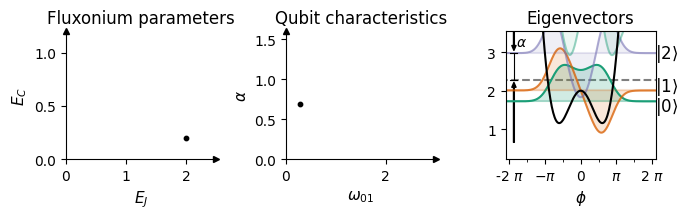

H is different
Fluxonium anharmonicity: 0.71 GHz
Fluxonium $\omega_{01}$: 0.3199841978182312 GHz
H is different
Fluxonium anharmonicity: 0.73 GHz
Fluxonium $\omega_{01}$: 0.35756007497556497 GHz
H is different
Fluxonium anharmonicity: 0.75 GHz
Fluxonium $\omega_{01}$: 0.394699466108418 GHz
H is different
Fluxonium anharmonicity: 0.77 GHz
Fluxonium $\omega_{01}$: 0.4313841626804862 GHz
H is different
Fluxonium anharmonicity: 0.79 GHz
Fluxonium $\omega_{01}$: 0.4676089402271639 GHz
H is different
Fluxonium anharmonicity: 0.80 GHz
Fluxonium $\omega_{01}$: 0.5033765626330489 GHz
H is different
Fluxonium anharmonicity: 0.82 GHz
Fluxonium $\omega_{01}$: 0.5386946731428253 GHz
H is different
Fluxonium anharmonicity: 0.84 GHz
Fluxonium $\omega_{01}$: 0.573573828024305 GHz
H is different
Fluxonium anharmonicity: 0.85 GHz
Fluxonium $\omega_{01}$: 0.6080262378530406 GHz
H is different
Fluxonium anharmonicity: 0.87 GHz
Fluxonium $\omega_{01}$: 0.6420649555823839 GHz
H is different
Fluxonium anharm

/tmp/ipykernel_1964863/868404974.py:335: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(rf'temp/eigenvecs_{i}.png'))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 229) to (704, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite
from math import factorial

# Parameters
phi_max = 10 * np.pi  # phase basis cutoff
N = 1000  # number of grid points
phi = np.linspace(-phi_max, phi_max, N)
dphi = phi[1] - phi[0]

def get_n2(N,max, periodic=False):
    arr_fund = [1/(dphi**2),-2/(dphi**2),1/(dphi**2)]
    arr = np.zeros((N,N))
    for i in range(N):
        for j in range(i-2,N):
            if i == j:
                arr[i][j] = arr_fund[1]
            elif i-j == 1 or i-j == -1:
                arr[i][j] = arr_fund[0]
            if j > i+1:
                break
    if periodic:
        arr[0][-1] = arr_fund[2]
        arr[-1][0] = arr_fund[2]
    return arr


energies = {
    "Fluxonium": {
        "EJ": 4.5,  # Josephson energy (in units of charging energy)
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.0,  # charging energy (in units of charging energy)
    },

}


# Function to diagonalize and plot eigenfunctions
smallest_y = 0.1
tallest_y = 1.0
colors = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
import pickle
import os
def eigs(V,T,name):
    H = V + T  # Hamiltonian
    if not os.path.exists(name+ "_H.pickle"):
        with open(name+ "_H.pickle", 'wb') as f:
            pickle.dump(np.zeros((N,N)), f)
    with open(name+ "_H.pickle", 'rb') as f:
        H_old = pickle.load(f)
        if H.shape == H_old.shape and np.allclose(H, H_old):
            print("H is the same")
            with open(name+ "_eigs.pickle", 'rb') as f:
                evals, evecs = pickle.load(f)
        else:
            print("H is different")
            evals, evecs = np.linalg.eigh(H)
            with open(name+ "_H.pickle", 'wb') as f:
                pickle.dump(H, f)
            with open(name+ "_eigs.pickle", 'wb') as f:
                pickle.dump((evals, evecs), f)
    return evals, evecs
    
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
def annotate_vertical_dimension(ax, x, y1, y2, label, color='black', 
                                 text_offset=0.05, linewidth=0.8, tick_size=0.3):
    # Ensure y1 is lower than y2
    y_lower, y_upper = sorted([y1, y2])

    

    # Horizontal ticks
    ax.plot([x - tick_size-0.05, x + tick_size], [y_lower, y_lower], color=color, linewidth=linewidth)
    ax.plot([x - tick_size-0.05, x + tick_size], [y_upper, y_upper], color=color, linewidth=linewidth)


    # Rotated label at the center
    avg = (y_lower + y_upper) / 2
    if np.abs(y1-y2) > 2:
        ax.text(x+0.05, avg+0.05, r'{}'.format(label),
                color=color, va='center', ha='center', rotation=0, fontsize=10)
        # Vertical line
        #ax.plot([x, x], [y_lower, avg-0.5], color=color, linewidth=linewidth)
        #ax.plot([x, x], [avg+0.5, y_upper], color=color, linewidth=linewidth)
        #add arrow in between
        """ax.annotate('', xy=(x, y_upper+0.25), xytext=(x, avg+0.5),
                    arrowprops=ArrowStyle('Fancy',head_length=0.5, tail_width=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg+0.5), (x, y_upper+0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

        """ax.annotate('', xy=(x, y_lower-0.25), xytext=(x, avg-0.5),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg-0.5), (x, y_lower-0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        
    else:
        ax.text(x+0.2, y_upper+0.1, r'{}'.format(label),
                color=color, va='bottom', ha='left', rotation=0,fontsize=10)
        # Vertical line
        ax.plot([x-0.01, x-0.01], [y_lower, y_upper], color=color, linewidth=linewidth)
        # add arrows pointing inwards
        ax.add_patch(FancyArrowPatch((x, y_upper+1.7), (x, y_upper),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        ax.add_patch(FancyArrowPatch((x, y_lower-1.7), (x, y_lower),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

def plot_eigenfunctions(phi, V, T, title, ax, n_levels=6):
    global smallest_y, tallest_y, colors    
    H = V + T  # Hamiltonian
    #evals, evecs = np.linalg.eigh(H)  # Eigenvalues and eigenvectors
    if "Transmon" in title:
        ext = np.pi
    else:
        ext = 2.1*np.pi
    evals, evecs = eigs(V,T,title)
    # Normalize eigenvectors
    for i in range(len(evecs[0,:])):
        evecs[:,i] /= np.sqrt(np.sum(evecs[:,i]**2)*dphi)
        if "Transmon" in title:
            evecs[:,i] *=2
    #make the unidirectional
    for i in range(len(evecs[:,])):
        for j in range(len(evecs[0,:])):
            if not np.isclose(evecs[j,i], 0):
                evecs[:,i] /= np.sign(evecs[j,i])
                break

    V_min = np.min(V)
    evals -= V_min  # Shift eigenvalues to start from zero
    V = V - V_min  # Shift potential to start from zero


    B = evecs
    #V = B @ V @ B.T
    #H0 = B @ H @ B.T
    H0 = np.diag(evals)
    
    anotcords = []
    for n in range(n_levels):
        ax.plot(phi, evecs[:, n]*2 + evals[n], label=f'n={n}', color=colors[n%3], alpha=np.exp(-n*3e-1))
        ax.fill_between(phi, evals[n], evals[n] + evecs[:, n]*2, color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        ax.plot(phi, [evals[n]]*len(phi), color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        va = "center"
        ofs = 0.0
        if "Fluxonium" in title:
            if n == 0:
                va = "top"
                ofs = 0.05
            elif n == 1:
                va = "bottom"
                ofs = -0.05
        anotcords.append(evals[n])
    while np.any(np.abs(np.diff(anotcords)) < 0.15*(evals[4]-evals[0])):
        for n in range(n_levels):
            if np.abs(anotcords[n] - anotcords[n-1]) < 0.15*(evals[4]-evals[0]) and n > 0:
                anotcords[n-1] -= 0.01
                anotcords[n] += 0.01
    for n in range(n_levels):
        ax.annotate(
            rf'$|{n}\rangle$', xy=(0, anotcords[n]), xytext=(4.10*ext/np.pi, anotcords[n]+(evecs[:, n]*2)[-1]),    
            fontsize=12, color="k", ha='right', va=va)
    ax.plot(phi, np.diag(V), 'k', label='Potential')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$\phi$', fontsize=11)

    #anharmonicity
    if "LC" not in title:
        ax.plot(phi, [evals[0]+2*(evals[1]-evals[0])]*len(phi), 'k--', alpha=0.5, zorder=-20)
        ts = 0.3
        x_shift = 0.0
        if "Transmon" in title:
            ts /= 2.0
        if "Fluxonium" in title:
            x_shift = 00
        annotate_vertical_dimension(ax, -2.8*ext/np.pi+x_shift, evals[2], evals[0]+2*(evals[1]-evals[0]), r'$\alpha$', color='k', text_offset=0.1, tick_size=ts)
        print(f'{title} anharmonicity: {(evals[2]-evals[1])-(evals[1]-evals[0]):.2f} GHz')
        print(rf'{title} $\omega_{{01}}$: {(evals[1]-evals[0])} GHz')
    
    #ax.grid(True)
    #ax.set_xlim(-phi_max/2, phi_max/2)
    if evals[0] < smallest_y:
        smallest_y = evals[0]
    if evals[n_levels-1] > tallest_y:
        tallest_y = evals[n_levels-1]
    ax.set_xlim(-ext, ext)
    if "LC" in title:
        ax.set_ylabel('Energy levels [GHz]',fontsize=12)

    #set tick font size
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    
    #set x-axis ticks in units of pi
    span = [-ext, ext]
    loc = ticker.MultipleLocator(np.pi)
    ax.xaxis.set_major_locator(loc)
    def func_format(x,_):
        string = f'{x/np.pi:.0f} $\pi$' if x != 0 else '0'
        if x/np.pi == 1:
            string = r'$\pi$'
        elif x/np.pi == -1:
            string = r'$-\pi$'
        return string
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(func_format))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi/2))
    return H0

Np = 40
ELs = [1]*Np
ECs = np.linspace(0.2, 1, Np).tolist()
EJs = [2]*Np

ELs = ELs + [1]*Np
ECs = ECs + [1]*Np
EJs = EJs + np.linspace(0.3, 2, Np).tolist()[::-1]

ELs = ELs + [1]*Np
ECs = ECs + np.linspace(0.2, 1, Np).tolist()[::-1]
EJs = EJs + [0.3]*Np

ELs = ELs + [1]*Np
ECs = ECs + [0.2]*Np
EJs = EJs + np.linspace(0.3, 2, Np).tolist()


cnt = 0
lastEs = []
lastCharcs = []
for i, EL, EC, EJ in zip(range(len(ELs)), ELs, ECs, EJs):
    # Kinetic energy

    #Ec = energies["Transmon"]["EC"]
    #T_trans = -4*Ec*get_n2(N, np.pi, periodic=True)
    #phi_trans = np.linspace(-np.pi, np.pi, N)
    #Ec = energies["LC circuit"]["EC"]
    #T_LC = -4*Ec*get_n2(N, phi_max, periodic=False)
    #Ec = energies["Fluxonium"]["EC"]
    T_flux = -4*EC*get_n2(N, phi_max, periodic=False)

    # LC circuit — simple harmonic oscillator
    V_LC = np.diag(0.5 * phi**2)

    # Transmon — cosine potential
    #EJ = energies["Transmon"]["EJ"]
    #V_Transmon = np.diag(-EJ * np.cos(phi_trans))

    # Fluxonium — cosine + parabolic offset (with external flux phi_ext=0)
    #EL = energies["Fluxonium"]["EL"]
    #EJ = energies["Fluxonium"]["EJ"]
    V_Fluxonium = np.diag(-EJ * np.cos(phi-np.pi) + 0.5 * EL * phi**2)


    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(7, 2.3), sharey=False, sharex=False)

    #plot_eigenfunctions(phi, V_LC, T_LC, 'LC circuit', axes[0])
    #plot_eigenfunctions(phi_trans, V_Transmon, T_trans, 'Transmon', axes[1])
    H0 = plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', axes[2])
    omega_04 = abs(H0[4,4]-H0[0,0])
    axes[2].set_title('Eigenvectors', fontsize=12)
    axes[2].set_ylim(H0[0,0]-1.5, 1*omega_04+H0[0,0]-1.5)

    #plot the two left axes
    axes[0].set_xlabel(r'$E_J$', fontsize=11)
    axes[0].set_ylabel(r'$E_C$', fontsize=11)
    axes[0].scatter(EJ, EC, c='k', s=10)
    axes[0].set_xlim(0, 2.5)
    axes[0].set_ylim(0, 1.2)
    axes[0].set_title('Fluxonium parameters', fontsize=12)
    axes[1].set_xlabel(r'$\omega_{01}$', fontsize=11)
    axes[1].set_ylabel(r'$\alpha$', fontsize=11)
    i = 0
    for EJ_l, EC_l in lastEs[::-1]:
        axes[0].scatter(EJ_l, EC_l, alpha=np.exp(-(i+1)/3), c='k', s=10)
        i += 1
    lastEs.append((EJ, EC))
    omega_01 = abs(H0[1,1]-H0[0,0])
    alpha = abs(H0[2,2]-H0[1,1]) - abs(H0[1,1]-H0[0,0])
    axes[1].scatter(omega_01, alpha, c='k', s=10)
    axes[1].set_title('Qubit characteristics', fontsize=12)
    axes[1].set_xlim(-0.001, 3)
    axes[1].set_ylim(0, 1.6)
    for i,charc in enumerate(lastCharcs[::-1]):
        omega_01_l, alpha_l = charc
        axes[1].scatter(omega_01_l, alpha_l, alpha=np.exp(-(i+1)/3), c='k', s=10)
    lastCharcs.append((omega_01, alpha))

    for ax in axes[:-1]:
        # Set bottom and left spines as x and y axes of coordinate system
        ax.spines['bottom'].set_position('zero')
        ax.spines['left'].set_position('zero')

        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Draw arrows
        arrow_fmt = dict(markersize=4, color='black', clip_on=False)
        ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
        ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)

    #set consistent ticks
    ticks = [i for i in range(10) if i < axes[2].get_ylim()[1] and i > axes[2].get_ylim()[0]]
    axes[2].set_yticks(ticks)
    axes[2].set_yticklabels([f'{i}' for i in ticks])
    if axes[2].get_ylim()[1] > 5:
        ticks = [i for i in range(0,20,2) if i < axes[2].get_ylim()[1] and i > axes[2].get_ylim()[0]]
        axes[2].set_yticks(ticks)
        axes[2].set_yticklabels([f'{i}' for i in ticks])

    fig.tight_layout()
    plt.savefig(rf'temp/eigenvecs_{cnt}.png')
    if cnt == 0:
        plt.show()
    cnt += 1
    plt.close(fig)

#stitch together to an mp4
import imageio
images = []
for i in range(cnt):
    images.append(imageio.imread(rf'temp/eigenvecs_{i}.png'))
imageio.mimsave('eigenvecs_fluxonium_1.mp4', images, fps=Np//2, quality=8)


H is different
Fluxonium anharmonicity: 0.01 GHz
Fluxonium $\omega_{01}$: 0.9915416912891039 GHz


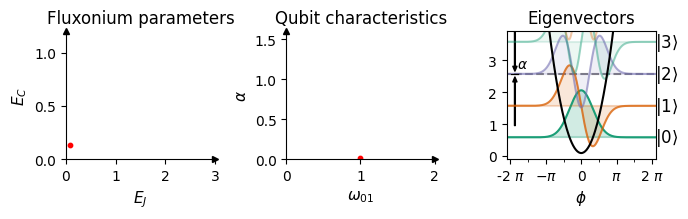

H is different
Fluxonium anharmonicity: 0.05 GHz
Fluxonium $\omega_{01}$: 1.0104265946714595 GHz
H is different
Fluxonium anharmonicity: 0.09 GHz
Fluxonium $\omega_{01}$: 0.9973196989299601 GHz
H is different
Fluxonium anharmonicity: 0.13 GHz
Fluxonium $\omega_{01}$: 0.9663990546570289 GHz
H is different
Fluxonium anharmonicity: 0.16 GHz
Fluxonium $\omega_{01}$: 0.9951019217589057 GHz
H is different
Fluxonium anharmonicity: 0.20 GHz
Fluxonium $\omega_{01}$: 0.9921057985768318 GHz
H is different
Fluxonium anharmonicity: 0.24 GHz
Fluxonium $\omega_{01}$: 0.9806329267667859 GHz
H is different
Fluxonium anharmonicity: 0.28 GHz
Fluxonium $\omega_{01}$: 1.0053624598742266 GHz
H is different
Fluxonium anharmonicity: 0.32 GHz
Fluxonium $\omega_{01}$: 0.9913566385426722 GHz
H is different
Fluxonium anharmonicity: 0.35 GHz
Fluxonium $\omega_{01}$: 0.9953187368940171 GHz
H is different
Fluxonium anharmonicity: 0.39 GHz
Fluxonium $\omega_{01}$: 0.9851274207555929 GHz
H is different
Fluxonium anhar

/tmp/ipykernel_1964863/2884910706.py:380: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(rf'temp/eigenvecs_{i}.png'))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 229) to (704, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite
from math import factorial

# Parameters
phi_max = 10 * np.pi  # phase basis cutoff
N = 1000  # number of grid points
phi = np.linspace(-phi_max, phi_max, N)
dphi = phi[1] - phi[0]

def get_n2(N,max, periodic=False):
    arr_fund = [1/(dphi**2),-2/(dphi**2),1/(dphi**2)]
    arr = np.zeros((N,N))
    for i in range(N):
        for j in range(i-2,N):
            if i == j:
                arr[i][j] = arr_fund[1]
            elif i-j == 1 or i-j == -1:
                arr[i][j] = arr_fund[0]
            if j > i+1:
                break
    if periodic:
        arr[0][-1] = arr_fund[2]
        arr[-1][0] = arr_fund[2]
    return arr


energies = {
    "Fluxonium": {
        "EJ": 4.5,  # Josephson energy (in units of charging energy)
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.0,  # charging energy (in units of charging energy)
    },

}


# Function to diagonalize and plot eigenfunctions
smallest_y = 0.1
tallest_y = 1.0
colors = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
import pickle
import os
def eigs(V,T,name):
    H = V + T  # Hamiltonian
    try:
        with open(name+ "_H.pickle", 'rb') as f:
            H_old = pickle.load(f)
    except EOFError:
        os.remove(name+ "_H.pickle")
    if not os.path.exists(name+ "_H.pickle"):
        with open(name+ "_H.pickle", 'wb') as f:
            pickle.dump(np.zeros((N,N)), f)
    with open(name+ "_H.pickle", 'rb') as f:
        H_old = pickle.load(f)
        if H.shape == H_old.shape and np.allclose(H, H_old):
            print("H is the same")
            with open(name+ "_eigs.pickle", 'rb') as f:
                evals, evecs = pickle.load(f)
        else:
            print("H is different")
            evals, evecs = np.linalg.eigh(H)
            with open(name+ "_H.pickle", 'wb') as f:
                pickle.dump(H, f)
            with open(name+ "_eigs.pickle", 'wb') as f:
                pickle.dump((evals, evecs), f)
    return evals, evecs
    
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
def annotate_vertical_dimension(ax, x, y1, y2, label, color='black', 
                                 text_offset=0.05, linewidth=0.8, tick_size=0.3):
    # Ensure y1 is lower than y2
    y_lower, y_upper = sorted([y1, y2])

    

    # Horizontal ticks
    ax.plot([x - tick_size-0.05, x + tick_size], [y_lower, y_lower], color=color, linewidth=linewidth)
    ax.plot([x - tick_size-0.05, x + tick_size], [y_upper, y_upper], color=color, linewidth=linewidth)


    # Rotated label at the center
    avg = (y_lower + y_upper) / 2
    if np.abs(y1-y2) > 2:
        ax.text(x+0.05, avg+0.05, r'{}'.format(label),
                color=color, va='center', ha='center', rotation=0, fontsize=10)
        # Vertical line
        #ax.plot([x, x], [y_lower, avg-0.5], color=color, linewidth=linewidth)
        #ax.plot([x, x], [avg+0.5, y_upper], color=color, linewidth=linewidth)
        #add arrow in between
        """ax.annotate('', xy=(x, y_upper+0.25), xytext=(x, avg+0.5),
                    arrowprops=ArrowStyle('Fancy',head_length=0.5, tail_width=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg+0.5), (x, y_upper+0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

        """ax.annotate('', xy=(x, y_lower-0.25), xytext=(x, avg-0.5),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg-0.5), (x, y_lower-0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        
    else:
        ax.text(x+0.2, y_upper+0.1, r'{}'.format(label),
                color=color, va='bottom', ha='left', rotation=0,fontsize=10)
        # Vertical line
        ax.plot([x-0.01, x-0.01], [y_lower, y_upper], color=color, linewidth=linewidth)
        # add arrows pointing inwards
        ax.add_patch(FancyArrowPatch((x, y_upper+1.7), (x, y_upper),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        ax.add_patch(FancyArrowPatch((x, y_lower-1.7), (x, y_lower),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

def plot_eigenfunctions(phi, V, T, title, ax, n_levels=6):
    global smallest_y, tallest_y, colors    
    H = V + T  # Hamiltonian
    #evals, evecs = np.linalg.eigh(H)  # Eigenvalues and eigenvectors
    if "Transmon" in title:
        ext = np.pi
    else:
        ext = 2.1*np.pi
    evals, evecs = eigs(V,T,title)
    # Normalize eigenvectors
    for i in range(len(evecs[0,:])):
        evecs[:,i] /= np.sqrt(np.sum(evecs[:,i]**2)*dphi)
        if "Transmon" in title:
            evecs[:,i] *=2
    #make the unidirectional
    for i in range(len(evecs[:,])):
        for j in range(len(evecs[0,:])):
            if not np.isclose(evecs[j,i], 0):
                evecs[:,i] /= np.sign(evecs[j,i])
                break

    V_min = np.min(V)
    evals -= V_min  # Shift eigenvalues to start from zero
    V = V - V_min  # Shift potential to start from zero


    B = evecs
    #V = B @ V @ B.T
    #H0 = B @ H @ B.T
    H0 = np.diag(evals)
    
    anotcords = []
    for n in range(n_levels):
        ax.plot(phi, evecs[:, n]*2 + evals[n], label=f'n={n}', color=colors[n%3], alpha=np.exp(-n*3e-1))
        ax.fill_between(phi, evals[n], evals[n] + evecs[:, n]*2, color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        ax.plot(phi, [evals[n]]*len(phi), color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        va = "center"
        ofs = 0.0
        if "Fluxonium" in title:
            if n == 0:
                va = "top"
                ofs = 0.05
            elif n == 1:
                va = "bottom"
                ofs = -0.05
        anotcords.append(evals[n])
    while np.any(np.abs(np.diff(anotcords)) < 0.15*(evals[4]-evals[0])):
        for n in range(n_levels):
            if np.abs(anotcords[n] - anotcords[n-1]) < 0.15*(evals[4]-evals[0]) and n > 0:
                anotcords[n-1] -= 0.01
                anotcords[n] += 0.01
    for n in range(n_levels):
        ax.annotate(
            rf'$|{n}\rangle$', xy=(0, anotcords[n]), xytext=(4.10*ext/np.pi, anotcords[n]+(evecs[:, n]*2)[-1]),    
            fontsize=12, color="k", ha='right', va=va)
    ax.plot(phi, np.diag(V), 'k', label='Potential')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$\phi$', fontsize=11)

    #anharmonicity
    if "LC" not in title:
        ax.plot(phi, [evals[0]+2*(evals[1]-evals[0])]*len(phi), 'k--', alpha=0.5, zorder=-20)
        ts = 0.3
        x_shift = 0.0
        if "Transmon" in title:
            ts /= 2.0
        if "Fluxonium" in title:
            x_shift = 00
        annotate_vertical_dimension(ax, -2.8*ext/np.pi+x_shift, evals[2], evals[0]+2*(evals[1]-evals[0]), r'$\alpha$', color='k', text_offset=0.1, tick_size=ts)
        print(f'{title} anharmonicity: {(evals[2]-evals[1])-(evals[1]-evals[0]):.2f} GHz')
        print(rf'{title} $\omega_{{01}}$: {(evals[1]-evals[0])} GHz')
    
    #ax.grid(True)
    #ax.set_xlim(-phi_max/2, phi_max/2)
    if evals[0] < smallest_y:
        smallest_y = evals[0]
    if evals[n_levels-1] > tallest_y:
        tallest_y = evals[n_levels-1]
    ax.set_xlim(-ext, ext)
    if "LC" in title:
        ax.set_ylabel('Energy levels [GHz]',fontsize=12)

    #set tick font size
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    
    #set x-axis ticks in units of pi
    span = [-ext, ext]
    loc = ticker.MultipleLocator(np.pi)
    ax.xaxis.set_major_locator(loc)
    def func_format(x,_):
        string = f'{x/np.pi:.0f} $\pi$' if x != 0 else '0'
        if x/np.pi == 1:
            string = r'$\pi$'
        elif x/np.pi == -1:
            string = r'$-\pi$'
        return string
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(func_format))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi/2))
    return H0

Np = 40

alphas = np.linspace(0.01, 1.5, Np).tolist()
alphas = alphas + [1.5]*(Np//2)
alphas = alphas + np.linspace(0.01, 1.5, Np).tolist()[::-1]
alphas = alphas + [0.01]*(Np//2)
length = len(alphas)
EL = 1
ECs = np.full(length, None)
EJs = np.full(length, None)
if "buffer_Es.pickle" not in os.listdir("temp"):
    pass
else:
    with open("temp/buffer_Es.pickle", 'rb') as f:
        ECs_l, EJs_l = pickle.load(f)
        if len(ECs_l) == length and len(EJs_l) == length:
            ECs = ECs_l
            EJs = EJs_l
    pass
omega_target = 1


cnt = 0
lastEs = []
lastCharcs = []

alpha_ICs = {
    0.01: [0.01, 1, 0.5],
    0.1: [0.05, 1, 1.08],
    1: [0.27, 1, 2.4],
    10: [2, 1, 10],
    20: [4.02, 1, 21.7],
}
import utils.qubit_init as qi
from scipy.optimize import minimize

#for i, EL, EC, EJ in zip(range(len(ELs)), ELs, ECs, EJs):
for i, alpha_target in zip(range(len(alphas)), alphas):
    # Kinetic energy
    H0 = np.zeros((N,N))
    """def loss(E):
        Ec, Ej = E
        if Ec < 0 or Ej < 0:
            return 1e10
        El = EL
        T_flux = -4*Ec*get_n2(N, phi_max, periodic=False)
        V_Fluxonium = np.diag(-Ej * np.cos(phi-np.pi) + 0.5 * El * phi**2)
        #H0 = plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', axes[2])
        #evals, evecs = eigs(T_flux,T_flux,'')
        #H0 = np.diag(evals)
        qi.init_qubit(None, 
        o = H0[1,1]-H0[0,0]
        a = H0[2,2]-H0[1,1] - (H0[1,1]-H0[0,0])
        return (o - omega_target)**4 + (a - alpha_target)**2 + (o - omega_target)**2"""
    if ECs[i] == None or EJs[i] == None:
        close_alpha_indx = np.argmin(np.abs(alpha_target - np.array(list(alpha_ICs.keys()))))
        Ec_I, _, Ej_I = alpha_ICs[list(alpha_ICs.keys())[close_alpha_indx]]
        #result = minimize(loss, [Ec_I,Ej_I], method='Nelder-Mead')
        H0, _, _, _, _, _, _, EC, _, EJ = qi.init_qubit(None, EL, None, np.pi, omega_target,alpha_target, None, None,truncation=5, base_ex=4*np.pi, base_size=2000,Ec_IC=Ec_I,El_IC=EL,Ej_IC=Ej_I)
        #EC = result.x[0]
        #EJ = result.x[1]
        ECs[i] = EC
        EJs[i] = EJ
        with open("temp/buffer_Es.pickle", 'wb') as f:
            pickle.dump((ECs, EJs), f)
    else:
        EC = ECs[i]
        EJ = EJs[i]
    T_flux = -4*EC*get_n2(N, phi_max, periodic=False)
    V_Fluxonium = np.diag(-EJ * np.cos(phi-np.pi) + 0.5 * EL * phi**2)
    minV = np.min(V_Fluxonium)
    
                          


    #Ec = energies["Transmon"]["EC"]
    #T_trans = -4*Ec*get_n2(N, np.pi, periodic=True)
    #phi_trans = np.linspace(-np.pi, np.pi, N)
    #Ec = energies["LC circuit"]["EC"]
    #T_LC = -4*Ec*get_n2(N, phi_max, periodic=False)
    #Ec = energies["Fluxonium"]["EC"]
    


    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(7, 2.3), sharey=False, sharex=False)

    #plot_eigenfunctions(phi, V_LC, T_LC, 'LC circuit', axes[0])
    #plot_eigenfunctions(phi_trans, V_Transmon, T_trans, 'Transmon', axes[1])
    H0 = plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', axes[2])
    
    omega_04 = abs(H0[4,4]-H0[0,0])
    axes[2].set_title('Eigenvectors', fontsize=12)
    axes[2].set_ylim(minV-0.1, 1*omega_04+minV-0.1)

    #plot the two left axes
    axes[0].set_xlabel(r'$E_J$', fontsize=11)
    axes[0].set_ylabel(r'$E_C$', fontsize=11)
    axes[0].scatter(EJ, EC, c='red', s=10)
    axes[0].set_xlim(0, 3)
    axes[0].set_ylim(0, 1.2)
    axes[0].set_title('Fluxonium parameters', fontsize=12)
    axes[1].set_xlabel(r'$\omega_{01}$', fontsize=11)
    axes[1].set_ylabel(r'$\alpha$', fontsize=11)
    i = 0
    for EJ_l, EC_l in lastEs[::-1]:
        axes[0].scatter(EJ_l, EC_l, alpha=np.exp(-(i+1)/3), c='red', s=10)
        i += 1
    lastEs.append((EJ, EC))
    omega_01 = abs(H0[1,1]-H0[0,0])
    alpha = abs(H0[2,2]-H0[1,1]) - abs(H0[1,1]-H0[0,0])
    axes[1].scatter(omega_01, alpha, c='red', s=10)
    axes[1].set_title('Qubit characteristics', fontsize=12)
    axes[1].set_xlim(-0.001, 2.01)
    axes[1].set_ylim(0, 1.6)
    for i,charc in enumerate(lastCharcs[::-1]):
        omega_01_l, alpha_l = charc
        axes[1].scatter(omega_01_l, alpha_l, alpha=np.exp(-(i+1)/3), c='red', s=10)
    lastCharcs.append((omega_01, alpha))

    for ax in axes[:-1]:
        # Set bottom and left spines as x and y axes of coordinate system
        ax.spines['bottom'].set_position('zero')
        ax.spines['left'].set_position('zero')

        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Draw arrows
        arrow_fmt = dict(markersize=4, color='black', clip_on=False)
        ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
        ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)

    #set consistent ticks
    ticks = [i for i in range(10) if i < axes[2].get_ylim()[1] and i > axes[2].get_ylim()[0]]
    axes[2].set_yticks(ticks)
    axes[2].set_yticklabels([f'{i}' for i in ticks])
    if axes[2].get_ylim()[1] > 5:
        ticks = [i for i in range(0,10,2) if i < axes[2].get_ylim()[1] and i > axes[2].get_ylim()[0]]
        axes[2].set_yticks(ticks)
        axes[2].set_yticklabels([f'{i}' for i in ticks])

    fig.tight_layout()
    plt.savefig(rf'temp/eigenvecs_{cnt}.png')
    if cnt == 0:
        plt.show()
    cnt += 1
    plt.close(fig)

#stitch together to an mp4
import imageio
images = []
for i in range(cnt):
    images.append(imageio.imread(rf'temp/eigenvecs_{i}.png'))
images = images# + [images[-1]]*10 + images[::-1]  # add reverse for the second half of the video
imageio.mimsave('eigenvecs_fluxonium_2.mp4', images, fps=Np//2, quality=8)


<Figure size 300x300 with 0 Axes>

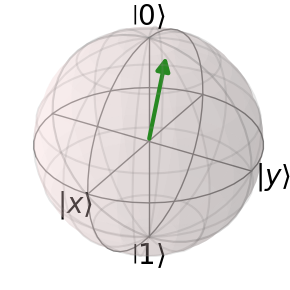

In [9]:
#use qutip to plot a bloch sphere
import matplotlib.pyplot as plt
from qutip import Bloch
#def plot_bloch_sphere(evecs, evals, title):
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')
b = Bloch(axes=ax, figsize=(3,3))
#replace x and y with kets of them

b.xlabel[0] = r'$|x\rangle$'
b.ylabel[0] = r'$|y\rangle$'

#add a state for demonstration
import qutip as qt
import numpy as np
x = 0.1
y = 0.2
z = 0.8
norm = np.sqrt(x**2 + y**2 + z**2)
x /= norm
y /= norm
z /= norm
b.add_vectors([x, y, z])

b.show()
#plt.title(title)
plt.tight_layout()
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


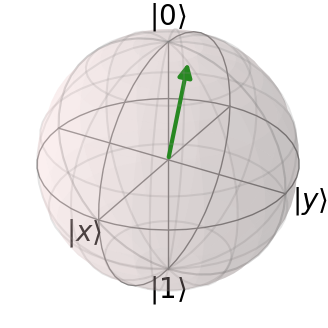

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from qutip import Bloch

# Initialize figure and Bloch sphere
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
b = Bloch(axes=ax)
b.xlabel = [r'$|x\rangle$', '']
b.ylabel = [r'$|y\rangle$', '']
b.zlabel = [r'$|0\rangle$', r'$|1\rangle$']

# Starting state vector (normalized)
x0, y0, z0 = 0.1, 0.2, 0.8
norm = np.sqrt(x0**2 + y0**2 + z0**2)
x0, y0, z0 = x0/norm, y0/norm, z0/norm

# Number of frames in the animation
num_frames = 20

# Relaxation parameters (adjust decay rates here)
T1 = 30  # longitudinal (z-axis) relaxation time constant
T2 = 20  # transverse (xy-plane) decoherence time constant

# Function to compute decayed state at time t
def relax_state(x0, y0, z0, t, T1, T2):
    x = x0 * np.exp(-t/T2)
    y = y0 * np.exp(-t/T2)
    z = z0 * np.exp(-t/T1) + (1 - np.exp(-t/T1)) * (-1)
    return [x, y, z]

# Update function for each frame
def update(frame):
    b.clear()
    t = frame
    state = relax_state(x0, y0, z0, t, T1, T2)
    b.add_vectors(state)
    b.make_sphere()
    return ax

# Create animation
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, blit=False)

# Save the animation as a GIF
ani.save('bloch_sphere_animation.gif', writer='imagemagick', fps=10)


MovieWriter imagemagick unavailable; using Pillow instead.


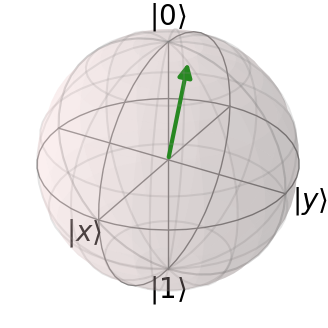

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from qutip import Bloch

# Initialize figure and Bloch sphere
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
b = Bloch(axes=ax)
b.xlabel = [r'$|x\rangle$', '']
b.ylabel = [r'$|y\rangle$', '']
b.zlabel = [r'$|0\rangle$', r'$|1\rangle$']

# Starting state vector (normalized)
x0, y0, z0 = 0.1, 0.2, 0.8
norm = np.sqrt(x0**2 + y0**2 + z0**2)
x0, y0, z0 = x0/norm, y0/norm, z0/norm
initial_state = np.array([x0, y0, z0])

# Number of frames in the animation
num_frames = 50

# Rotation parameters
omega = 2 * np.pi / num_frames  # rotation angle per frame (full 2pi cycle over num_frames)

# Function to rotate the state vector around the X-axis
def rotate_x(state, theta):
    R_x = np.array([[np.cos(theta), -np.sin(theta), 0],
                    [np.sin(theta),  np.cos(theta), 0],
                    [0, 0, 1]])
    return R_x @ state

# Update function for each frame
def update(frame):
    b.clear()
    theta = omega * frame
    state = rotate_x(initial_state, theta)
    b.add_vectors(state)
    b.make_sphere()
    return ax

# Create animation
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, blit=False)

# Save the animation as a GIF
ani.save('bloch_z_rotation.gif', writer='imagemagick', fps=10)


<Figure size 300x300 with 0 Axes>

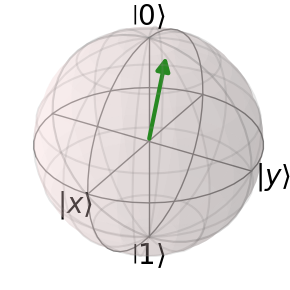

In [12]:
#use qutip to plot a bloch sphere
import matplotlib.pyplot as plt
from qutip import Bloch
#def plot_bloch_sphere(evecs, evals, title):
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')
b = Bloch(axes=ax, figsize=(3,3))
#replace x and y with kets of them
b.xlabel[0] = r'$|x\rangle$'
b.ylabel[0] = r'$|y\rangle$'

#make the sphere simplistic; no frame, no grid, no axes
pass


#add a state for demonstration
import qutip as qt
import numpy as np
x = 0.1
y = 0.2
z = 0.8
norm = np.sqrt(x**2 + y**2 + z**2)
x /= norm
y /= norm
z /= norm
b.add_vectors([x, y, z])

b.show()
#plt.title(title)
plt.tight_layout()
plt.show()

In [13]:
#sketch a photon wave packet
import numpy as np
import matplotlib.pyplot as plt

MovieWriter imagemagick unavailable; using Pillow instead.


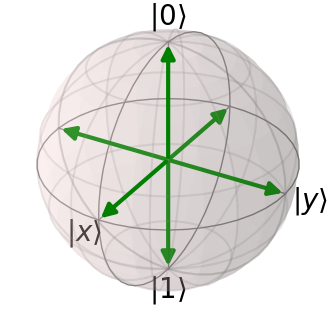

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from qutip import Bloch

# Initialize figure and Bloch sphere
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
b = Bloch(axes=ax)
b.xlabel = [r'$|x\rangle$', '']
b.ylabel = [r'$|y\rangle$', '']
b.zlabel = [r'$|0\rangle$', r'$|1\rangle$']

# Starting state vector (normalized)
init_states = [
    np.array([0, 0, 1]),  # |0>
    np.array([0, 0, -1]),  # |1>
    np.array([1, 0, 0]),  # |+x>
    np.array([-1, 0, 0]),  # |-x>
    np.array([0, 1, 0]),  # |+y>
    np.array([0, -1, 0]),  # |-y>
]
for state in init_states:
    x0, y0, z0 = state
    norm = np.sqrt(x0**2 + y0**2 + z0**2)
    x0, y0, z0 = x0/norm, y0/norm, z0/norm
    initial_state = np.array([x0, y0, z0])

# Number of frames in the animation
num_frames = 50

# Rotation parameters
omega = 0.5 * np.pi / num_frames  # rotation angle per frame (full 2pi cycle over num_frames)

# Function to rotate the state vector around the X-axis
def rotate_x(state, theta):
    R_x = np.array([[1, 0, 0],
                    [0, np.cos(theta), -np.sin(theta)],
                    [0, np.sin(theta),  np.cos(theta)]])
    return R_x @ state

def rotate_multiplier(frame):
    if frame < num_frames / 5:
        return 0
    elif frame > num_frames * 4 / 5:
        return 1
    t = frame / num_frames
    return 0.5 - 0.5*np.cos(np.pi * (t - 0.2) / 0.6)  # Smooth transition multiplier

# Update function for each frame
def update(frame):
    b.clear()
    theta = omega * frame
    theta *= rotate_multiplier(frame)  # Apply smooth transition multiplier
    for state in init_states:
        state = rotate_x(state, theta)
        b.add_vectors(state, colors=['g'])
    b.make_sphere()
    return ax

# Create animation
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, blit=False)

# Save the animation as a GIF
ani.save('bloch_x_rotation.gif', writer='imagemagick', fps=30)


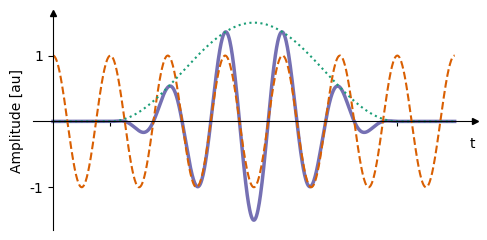

In [15]:
### carrier and envelope plot
import numpy as np
import matplotlib.pyplot as plt
t_0 = 0.2  # Time offset for the envelope
t_g = 1.0  # Duration of the envelope
carrier = lambda t: np.cos(2 * np.pi * 5 * t)  # Carrier wave
def envelope(t):
    mask = np.logical_or(t < t_0, t > t_0 + t_g)  # Define the mask for the envelope
    arr = np.zeros_like(t)
    arr[mask] = 0
    t_loc = t[~mask]
    arr[~mask] = 0.75*(1 - np.cos(2 * np.pi * (t_loc - t_0))) # Envelope function
    return arr

T = np.linspace(0, t_0+t_g+t_0, 1000)  # Time vector
env = envelope(T)
modulated_signal = carrier(T) * env  # Amplitude modulated signal
plt.figure(figsize=(5, 2.5))
colors = {
    "1": "#d95f02",
    "2": "#7570b3",
    "3": "#1b9e77"
}
plt.plot(T, modulated_signal, label='Modulated Signal', color=colors["2"], linewidth=2.5)
plt.plot(T, carrier(T), label='Carrier Wave', linestyle='--', color=colors["1"])
plt.plot(T, envelope(T), label='Envelope', linestyle=':', color=colors["3"])
#plt.title('Amplitude Modulation: Carrier and Envelope')
plt.xlabel('t', loc='right')
plt.ylabel('Amplitude [au]')
#plt.legend()
#plt.grid()

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Set bottom and left spines as x and y axes of coordinate system
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')

arrow_fmt = dict(markersize=4, color='black', clip_on=False)
ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)

ax.set_xticks([t_0, t_0+t_g])
ax.set_xticklabels(['', ''])
ax.set_yticks([-1,1])
ax.set_yticklabels([-1, 1], fontsize=10)


plt.tight_layout()
plt.savefig('amplitude_modulation.png')
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


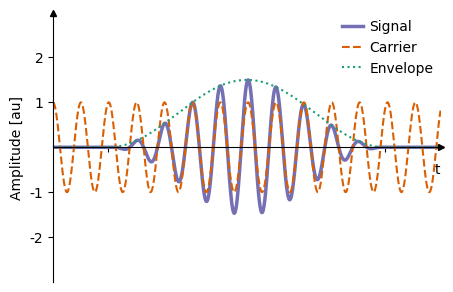

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Envelope parameters
t_0 = 0.2
t_g = 1.0

# Time vector
T = np.linspace(0, t_0 + t_g + t_0, 1000)

# Envelope function
def envelope(t):
    mask = np.logical_or(t < t_0, t > t_0 + t_g)
    arr = np.zeros_like(t)
    t_loc = t[~mask]
    arr[~mask] = 0.75 * (1 - np.cos(2 * np.pi * (t_loc - t_0)))
    return arr

env = envelope(T)

# Set up figure and axes
fig, ax = plt.subplots(figsize=(5, 3.5))

# Initial plot elements (empty, to be updated)
colors = {
    "1": "#d95f02",
    "2": "#7570b3",
    "3": "#1b9e77"
}
mod_line, = ax.plot([], [], label='Signal', color=colors["2"], linewidth=2.5)
carrier_line, = ax.plot([], [], label='Carrier', linestyle='--', color= colors["1"])
env_line, = ax.plot(T, env, label='Envelope', linestyle=':', color= colors["3"])

# Set up axes
ax.set_xlabel('t', loc='right')
ax.set_ylabel('Amplitude [au]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')

arrow_fmt = dict(markersize=4, color='black', clip_on=False)
ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)

ax.set_xticks([t_0, t_0 + t_g])
ax.set_xticklabels(['', ''])
ax.set_yticks([-2,-1, 1, 2])
ax.set_yticklabels([-2,-1, 1,2], fontsize=10)

ax.set_xlim(T[0], T[-1])
ax.set_ylim(-3, 3)
ax.legend(loc='upper right', fontsize=10,
              frameon=False, handlelength=1.5, handletextpad=0.5,
                borderpad=0.0, labelspacing=0.5, markerscale=1.2)

# Animation function
def update(frame):
    freq = 3 + 7 * frame / 100  # Sweep from 3 Hz to 10 Hz over 100 frames
    carrier = np.cos(2 * np.pi * freq * T)
    modulated_signal = carrier * env
    mod_line.set_data(T, modulated_signal)
    carrier_line.set_data(T, carrier)
    return mod_line, carrier_line

# Create animation
ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)

#save the animation as a GIF
ani.save('amplitude_modulation_animation.gif', writer='imagemagick', fps=20)


<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_3433732/3832581897.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


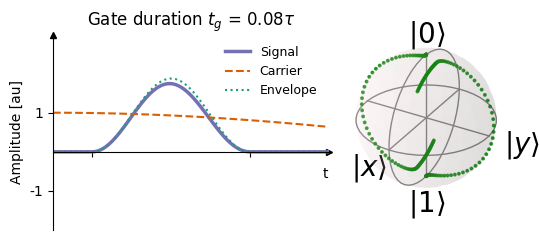

<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_3433732/3832581897.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_3433732/3832581897.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_3433732/3832581897.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_3433732/3832581897.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3433732/3832581897.py:180: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(f'temp/amplitude_modulation_frame_{i:03d}.png'))
/tmp/ipykernel_3433732/3832581897.py:182: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(f'temp/amplitude_modulation_frame_{N-i-1:03d}.png'))
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_siz

Video saved to amplitude_modulation_animation.mp4


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from qutip import Bloch
import qutip as qt

# Envelope parameters
t_0 = 0.2
t_g = 0.8

# Time vector
T = np.linspace(0, t_0 + t_g + t_0+0.2, 100)

# Envelope function
def envelope(t):
    if isinstance(t, int) or isinstance(t, float):
        t = np.array([t])
    mask = np.logical_or(t < t_0, t > t_0 + t_g)
    arr = np.zeros_like(t)
    t_loc = t[~mask]
    arr[~mask] = 0.75 * (1 - np.cos(2 * np.pi * (t_loc - t_0)/ t_g))/t_g
    return arr

def vector_to_spinor(x, y, z):
    # Normalize the vector
    norm = np.sqrt(x**2 + y**2 + z**2)
    if norm == 0:
        raise ValueError("Zero vector cannot be converted to a spinor.")
    x, y, z = x / norm, y / norm, z / norm

    # Convert to spherical coordinates
    theta = np.arccos(z)
    phi = np.arctan2(y, x)

    # Compute spinor components
    spinor = np.array([
        np.cos(theta / 2),
        np.exp(1j * phi) * np.sin(theta / 2)
    ])

    return spinor
def spinor_to_vector(spinor):
    a, b = spinor
    # Ensure normalization
    norm = np.sqrt(np.abs(a)**2 + np.abs(b)**2)
    if norm == 0:
        raise ValueError("Zero spinor cannot be converted to a vector.")
    a, b = a / norm, b / norm

    x = 2 * np.real(np.conj(a) * b)
    y = 2 * np.imag(np.conj(a) * b)
    z = np.abs(a)**2 - np.abs(b)**2

    return np.array([x, y, z])


# Animation function
def genframe(frame):
    # Set up figure and axes
    fig, axs = plt.subplots(1,2,figsize=(5.5, 2.5), gridspec_kw={'width_ratios': [1.5, 1]})
    ax = axs[0]
    axs[1].set_axis_off()  # Hide the second axis
    #add an ax_bloch to the right of the main ax
    ax_bloch = fig.add_axes([0.63, 0.1, 0.3, 0.8], projection='3d')

    # Initial plot elements (empty, to be updated)
    #mod_line, = ax.plot([], [], label='Signal, color='blue')
    #carrier_line, = ax.plot([], [], label='Carrier', linestyle='--', color='orange')
    #env_line, = ax.plot(T, env, label='Envelope', linestyle=':', color='green')

    # Set up axes
    ax.set_xlabel('t', loc='right')
    ax.set_ylabel('Amplitude [au]')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')

    arrow_fmt = dict(markersize=4, color='black', clip_on=False)
    ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
    ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)

    ax.set_xticks([t_0, t_0 + t_g])
    ax.set_xticklabels(['', ''])
    ax.set_yticks([-1, 1])
    ax.set_yticklabels([-1, 1], fontsize=10)

    ax.set_xlim(T[0], T[-1])
    ax.set_ylim(-2, 3)
    env = envelope(T)
    freq = -0.9 + np.power(10,frame/N)
    carrier = np.cos(2 * np.pi * freq * T)
    modulated_signal = carrier * env
    colors = {
        "1": "#d95f02",
        "2": "#7570b3",
        "3": "#1b9e77"
    }
    ax.plot(T, modulated_signal, label='Signal', color=colors["2"], linewidth=2.5)
    ax.plot(T, carrier, label='Carrier', linestyle='--', color= colors["1"])
    ax.plot(T, env, label='Envelope', linestyle=':', color= colors["3"])
    #mod_line.set_data(T, modulated_signal)
    #carrier_line.set_data(T, carrier)
    #return mod_line, carrier_line

    t_gbytau = t_g*freq # Duration of the envelope in units of the carrier period
    ax.set_title(rf'Gate duration $t_g$ = {t_gbytau:.2f}$\tau$', fontsize=12)

    # Plot Bloch sphere
    b = Bloch(axes=ax_bloch)
    b.xlabel = [r'$|x\rangle$', '']
    b.ylabel = [r'$|y\rangle$', '']
    b.zlabel = [r'$|0\rangle$', r'$|1\rangle$']

    #rmove the grid and frame
    b.sphere_alpha = 0.1
    b.frame_alpha = 0.0
    b.xlpos = [1.5,-1.5]
    b.ylpos = [1.5,-1.5]
    b.zlpos = [1.3,-1.5]

    #evolve the state with the given envelope
    init_states = [
        np.array([0, 0, 1]),  # |0>
        np.array([1, 0, 0]),  # |+x>
        np.array([0, 1, 0]),  # |+y>
        np.array([0, 0, -1]),  # |1>
        np.array([-1, 0, 0]),  # |-x>
        np.array([0, -1, 0]),  # |-y>
    ]
    def H(t):
        return envelope(t) * (1+ np.cos(2 * np.pi * freq * t)) * qt.Qobj(np.array([[0, 1], [1, 0]]))  + np.sin(2 * np.pi * freq * t) * qt.Qobj(np.array([[0, -1j], [1j, 0]]))
    cs = [
        'g',
        'b',
        'r',
    ]
    for i,state in enumerate(init_states):
        if i%3 == 2: continue
        if i%3 == 1: continue
        c = cs[i%len(cs)]
        H_evol = qt.QobjEvo(H)
        state = qt.Qobj(vector_to_spinor(*state))
        states = qt.sesolve(H_evol, state, T)
        for s in states.states:
            s = s.full().flatten()
            x, y, z = spinor_to_vector(s)
            #norm = np.sqrt(x**2 + y**2 + z**2)
            #x, y, z = x/norm, y/norm, z/norm

            #b.add_vectors([x, y, z], colors=['g'])
            b.add_points([x, y, z],meth='s',colors=[c], alpha=0.5)
    b.point_size = [3]*4
    b.point_marker = ['o']*4
    b.make_sphere()
    b.show()
    legend = ax.legend(loc='upper right', fontsize=9, frameon=False)
    for t in legend.get_texts():
        t.set_ha('right') # ha is alias for horizontalalignment

    plt.tight_layout()
    plt.savefig(f'temp/amplitude_modulation_frame_{frame:03d}.png')
    if frame == 0:
        plt.show()
    else:
        plt.close(fig)


# Create animation
N = 200
#ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)
for i in range(N):
    genframe(i)

#take frames and create a gif
import os
import imageio
frames = []
for i in range(N):
    frames.append(imageio.imread(f'temp/amplitude_modulation_frame_{i:03d}.png'))
for i in range(N):#and back
    frames.append(imageio.imread(f'temp/amplitude_modulation_frame_{N-i-1:03d}.png'))
#imageio.mimsave('amplitude_modulation_animation.gif', frames, fps=20)
#save as mp4 instead
#imageio.mimsave('amplitude_modulation_animation.mp4', frames, fps=20)
def frames_to_mp4(frames, output_path, fps=24, codec='libx264', quality=8):
    """
    Convert a list of image frames (numpy arrays) into an MP4 video.

    Parameters:
        frames (list of np.ndarray): List of image frames (all same size and dtype).
        output_path (str): Path to the output MP4 file.
        fps (int): Frames per second for the output video.
        codec (str): Video codec (default 'libx264').
        quality (int): Quality setting (higher is better quality, 0–10 for imageio; default 8).
    """
    if not frames:
        raise ValueError("The frame list is empty.")

    height, width = frames[0].shape[:2]
    for i, frame in enumerate(frames):
        if frame.shape[:2] != (height, width):
            raise ValueError(f"Frame {i} has a different size than the first frame.")

    writer = imageio.get_writer(output_path, fps=fps, codec=codec, quality=quality)

    for frame in frames:
        writer.append_data(frame)

    writer.close()
    print(f"Video saved to {output_path}")

frames_to_mp4(frames, 'amplitude_modulation_animation.mp4', fps=20*N//100, codec='libx264', quality=8)



In [ ]:
from qiskit.visualization import plot_bloch_vector
fig = plot_bloch_vector([1, 0, 0], title="Bloch Sphere")
fig.savefig('bloch_sphere.pdf')
plt.show()


In [ ]:
%load_ext autoreload
%autoreload

import os
import pickle
if "config.txt" in os.listdir(): 
    os.remove("config.txt")
with open("config.txt", "a") as f:
    f.write(f"bloch: True\n")

with open("../scores_withmeta_onlyRWA.pickle", "rb") as f:
    scores = pickle.load(f)
    scores = scores["RWA_x_nooptim"]
    Lambdas = []
    fidelity = []
    for i in range(len(scores)):
        Lambdas.append(scores[i]["Lambdas"])
        fidelity.append(scores[i]["score"])

#plot the population transfer on a bloch sphere
from utils.eval_functions import do_test, AdaptiveLearner, calib_gate
from utils.gate_params import get_gate_params
import utils.gate_evaluator
import numpy as np
from matplotlib import pyplot as plt
gate_names_2_eval = [#actual values are hidden off in the other file
    #"commensurate_x_virt_z_nooptim",
    "FAST-MAGNUS_nooptim",
    #"commensurate_x_virt_z",
    "FAST-DRAG_nooptim",
    "RWA_x_nooptim",
    #"corotating_xy_virt_z",
    "magnus1_x_virt_z_nooptim",
    "corotating_xy_virt_z_nooptim",
    #"magnus1_x_virt_z",
]
gate = get_gate_params(gate_names_2_eval[2])
learner = AdaptiveLearner([], [None, 1, None, 1, 1, np.pi, (1.0,1.01), np.inf, np.inf], framework="random",truncation=2)
qubits_2_eval = learner.get_next_dp(N=1)
for i in range(len(qubits_2_eval)):
    qubits_2_eval[i]["Ec_IC"] = 1
    qubits_2_eval[i]["El_IC"] = 1
    qubits_2_eval[i]["Ej_IC"] = 1
qubits_2_eval[0], gate = calib_gate((qubits_2_eval[0], gate))

s,_=do_test(qubits_2_eval[0],gate)

ax = utils.gate_evaluator.axs[2]
sort = np.argsort(Lambdas)
Lambdas = np.array(Lambdas)[sort]
fidelity = np.array(fidelity)[sort]
#put a star denoting where the l.h.s. plot is on the right axis
lmbda = 1.0
fid = 1-s[0]
ax.plot([lmbda], [fid], marker='*', markersize=5, color='black', label='LHS plot point', zorder=10)
ax.plot(Lambdas, 1-np.array(fidelity), color='red', label='Fidelity', linewidth=1)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$t_g/\tau$', fontsize=9, labelpad=0)
axt = ax.twinx()
axt.set_yscale('log')
axt.set_ylim(ax.get_ylim())
ax.set_yticks([])
ax.set_yticklabels([])
axt.set_ylabel('Infidelity [1-F]', fontsize=9)
ax.set_xlim(0.2,10)
axt.set_yticks([1e-6,1e-4, 1e-2, 1])
axt.set_yticklabels([r'$10^{-6}$', r'$10^{-4}$',r'$10^{-2}$', '1'], fontsize=9)
#x tick size
ax.set_xticks([0.3, 1, 3, 10])
ax.set_xticklabels([r'$0.3$', r'$1$', r'$3$', r'$10$'], fontsize=9)
#get the minor ticks from the left yaxis and put them on the right
minor_ticks = ax.get_yticks(minor=True)
axt.set_yticks(minor_ticks, minor=True)
axt.set_yticks([1e-3, 1e-2, 1e-1, 1])
axt.set_yticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1'], fontsize=9)
axt.set_ylim(ax.get_ylim())
ax.set_yticks([], minor=True)

#get the markers on ax1 and reformat them
ax1 = utils.gate_evaluator.axs[1]
print(ax1.collections)
print(ax1.lines)
b = utils.gate_evaluator.bloch
print(b.point_alpha)
types = b.point_style
for i in range(len(b.point_size)):
    if i == 3:
        b.point_size[i] = 1
        b.point_marker[i] = ' '
    b.point_size[i] = 10
    b.point_marker[i] = '.'
for i in range(len(b.point_alpha)):
    if types[i] != 'l':
        b.point_alpha[i] = 0.2
    #b.point_color[i] = 'black'
#b.point_default_color[-1] = b.point_default_color[-2]
b.show()

#plt.tight_layout()
plt.tight_layout(pad=0,w_pad=0,h_pad=0)
plt.savefig("bloch_sphere.pdf", bbox_inches='tight')
plt.show()


Optimizing qubitoptimm_None,1,None,3.141592653589793,1,1,18.84955592153876,2000,50
Found cached optimization, loading...
Loaded
Optimized: [0.45008249 1.48827642]


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}


Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 0.3141483350441681
[1.+0.j 0.+0.j]
Testing at t0 = 0.6282966700883362
[1.+0.j 0.+0.j]
Testing at t0 = 0.9424450051325044
[1.+0.j 0.+0.j]
Testing at t0 = 1.2565933401766725
[1.+0.j 0.+0.j]
Testing at t0 = 1.5707416752208405
[1.+0.j 0.+0.j]
Testing at t0 = 1.8848900102650088
[1.+0.j 0.+0.j]
Testing at t0 = 2.1990383453091766
[1.+0.j 0.+0.j]
Testing at t0 = 2.513186680353345
[

capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 

/tmp/ipykernel_46138/2555365168.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


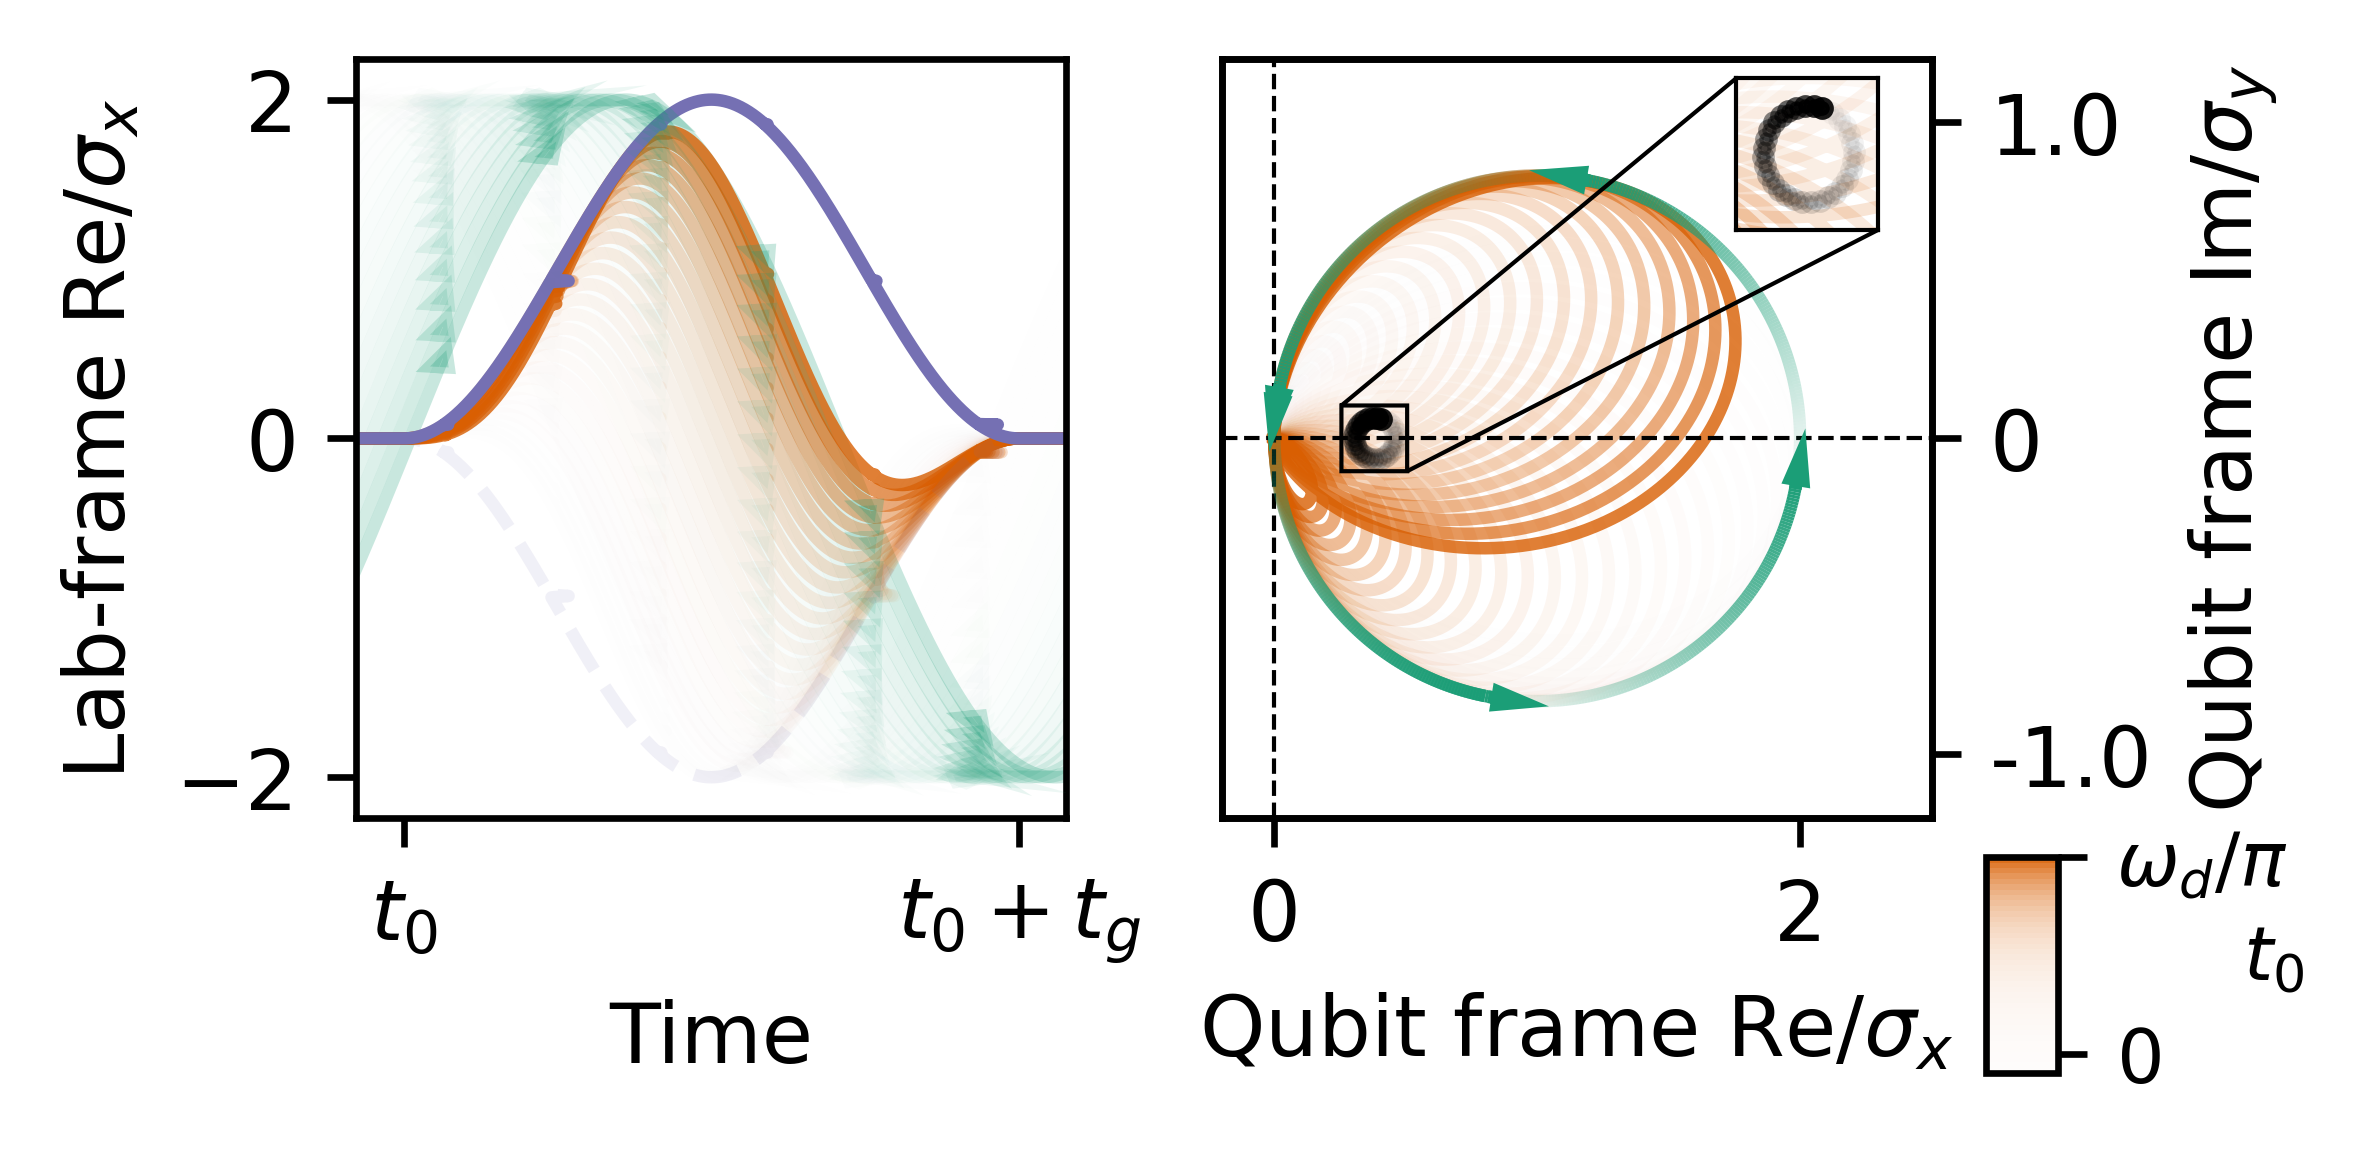

In [ ]:
#create a phase-space illustration of the |1><0| matrix element under a drive envelope
import numpy as np
import matplotlib.pyplot as plt


#for omega_d in np.linspace(0.5, 2.5, 20)*np.pi:
omega_d = 1.1*np.pi
alpha = 0.8
alpha2 = 0.9
fig, ax = plt.subplots(1, 2, figsize=(4, 2),dpi=600)
dt_0 = 0.7
#zoomin
e = 0.25
a_x, a_y = 0.38, 0
x1,x2 = a_x-e/2, a_x+e/2
y1,y2 = a_y-e/2, a_y+e/2
axins = ax[1].inset_axes(
    [0.725, 0.775, 0.2, 0.2],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[],xticks=[], yticks=[],
)
ax[1].indicate_inset_zoom(axins, edgecolor="black", lw=0.5, alpha=1, ls='-')
for k in axins.spines.keys():
    axins.spines[k].set_linewidth(0.5)

t_0s = np.linspace(0, omega_d/np.pi, 40)
clrs = []
for t_0 in t_0s:
    t_0 += dt_0
    #t_0 = 0.1
    cs = [
        '#1b9e77',
        '#d95f02',
        '#7570b3'
    ]
    t_g = 1.3
    #omega_d = 1.4*np.pi
    X = np.linspace(-0.2, t_g+0.2, 1000, dtype=np.float64)
    period = np.pi/ omega_d
    period_idx = np.argmin(np.abs(X+0.2 - period))
    global_shift = np.argmin(np.abs(X))
    #envelope = np.piecewise(X, [False, True], [lambda x: 1-np.cos(2*np.pi*(x-t_0)/t_g), 0])
    def envelope_func(t):
        if t < 0 or t >  t_g:
            return 0
        else:
            return float(1 - np.cos(2 * np.pi * (t) / t_g))
    envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
    element = 1+ np.exp(2j * (omega_d * X+omega_d * t_0+omega_d*t_g/2))
    element_0 = np.cos(omega_d * X+omega_d * t_0+omega_d*t_g/2)
    eelem = element * envelope/2
    eelem_0 = 2*(element_0) * envelope
    
    if True: #np.isclose(t_0,dt_0):
        ax[0].plot(X, 2*element_0, label='Matrix Element', color=cs[0], alpha=0.3*alpha)
        #make arrows for bits of the envelope
        s = 100
        for shift in range(0, len(X), period_idx//4):
            if shift < period_idx//4:
                continue
            bit_X = X[shift-s:shift-s+2]
            bit_Y = (2*element_0)[shift-s:shift-s+2].astype(np.float64)
            l = np.linalg.norm([bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0]])
            bit_X[1] = bit_X[0] + 0.05 * ((bit_X[1]-bit_X[0]) / l)
            bit_Y[1] = bit_Y[0] + 0.05 * ((bit_Y[1]-bit_Y[0]) / l)
            ax[0].arrow(bit_X[0], bit_Y[0], bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0],
                        head_width=0.04, head_length=0.1, fc=cs[0], ec=cs[0], lw=1.5, zorder=10,alpha=0.3*alpha,
                        length_includes_head=True)
    #two subplot, one for the time-axis envelope, and one for phase space
    
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel(rf'Lab-frame Re/$\sigma_x$')
    #ax[0].set_title('Real signal component vs. time')
    #ax[0].grid(True)
    
    ax[1].plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    ax[1].scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    ax[0].plot(X, np.real(eelem_0/2), label='Matrix Element', color=cs[1], alpha=alpha)
    axins.plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    axins.scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    hex2rgb = lambda h: tuple(int(h[i:i+2], 16) for i in (1, 3, 5))
    clr = hex2rgb(cs[1])
    rgba = (clr[0]/255, clr[1]/255, clr[2]/255, alpha2)
    clrs.append(rgba)
    alpha *= 0.8
    alpha2 *= 0.9
    
    

ax[0].plot(X, envelope, label='Drive Envelope', color=cs[2],alpha=1)
ax[0].plot(X, -envelope, label='Drive Envelope', color=cs[2],alpha=0.1, ls='--')


    
ax[1].set_xlabel('Qubit frame Re/$\sigma_x$')
#ax[1].set_ylabel(fr'Qubit frame Im/$\sigma_y$')
ax[1].set_yticks([])
ax[1].set_yticklabels([])
#ax[1].set_title(fr'$|1\rangle\langle0|$ element phase')
#ax[1].grid(True)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlim(-0.2, 2.5)
ax[1].set_ylim(-1.5, 1.5)
#ax[0].legend()
#ax[1].legend()
ax[1].axhline(0, color='black', lw=0.5, ls='--')
ax[1].axvline(0, color='black', lw=0.5, ls='--')
from matplotlib import patches
style = "C"
if style == "A":
    ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=cs[0])
if style == "B":
    a1 = patches.FancyArrowPatch((1, 1), (2, 0),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a2 = patches.FancyArrowPatch((2, 0), (1, -1),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a3 = patches.FancyArrowPatch((1, -1), (0, 0),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a4 = patches.FancyArrowPatch((0, 0), (1, 1),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    ax[1].add_patch(a3)
    ax[1].add_patch(a4)
    ax[1].add_patch(a1)
    ax[1].add_patch(a2)
if style == "C":
    """ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=cs[0], alpha=0.5)
    ax[1].scatter(np.mean(np.real(element)), np.mean(np.imag(element)), color="black", s=6, label='Mean Element', alpha=alpha2, zorder=10)
    ax[1].plot([0, 1], [0, 1], color=cs[0], lw=0.5, ls='--', alpha=0.5)
    ax[1].plot([0, 2], [0, 0], color=cs[0], lw=0.5, ls='--', alpha=0.5)"""

    #h = input('Enter hex: ').lstrip('#')
    rgb = tuple(int(cs[0][i+1:i+3], 16) for i in (0, 2, 4))
    rgba_s = [
        (rgb[0]/255, rgb[1]/255, rgb[2]/255, x*4) for x in np.linspace(0, 1, len(element[:period_idx]))
    ]

    #cs_arr1 = 
    #ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=rgba_s)
    #use lineconnection to plot the element with the specified colors
    # Create line segments for phase space trajectory
    from matplotlib.collections import LineCollection
    for shift in range(0, period_idx, period_idx//4):
        points = np.array([np.real(element[shift:shift+period_idx//4]), np.imag(element[shift:shift+period_idx//4])]).T
        segments = np.stack([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors=rgba_s[:-1], linewidths=1.5, label='Matrix Element')
        ax[1].add_collection(lc)
        endbit = segments[:1]
        #ax[1].plot(endbit[:, 0], endbit[:, 1], lw=1.5, color="red")
        #use endbit to plot an arrow
        """endbit -= 1
        endbit *= 1.1
        endbit += 1"""
        ax[1].arrow(endbit[0][0][0], endbit[0][0][1], endbit[0][1][0]-endbit[0][0][0], endbit[0][1][1]-endbit[0][0][1],
                    head_width=0.05, head_length=0.1, fc=cs[0],ec=cs[0], lw=1.5, zorder=10)
    

#set a star for reference
ax[0].set_xlim(-0.1,t_g+0.1)
#ax[0].scatter(0.56, 1.8, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[1].scatter(1.75, 0.4, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[0].scatter(1.04, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[1].scatter(0.15, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
ax[0].set_xticks([0, t_g])
ax[0].set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
axt = ax[1].twinx()
axt.set_ylabel(rf'Qubit frame Im/$\sigma_y$')
axt.set_ylim(-1.2, 1.2)
axt.set_yticks([-1.0,0,1.0])
axt.set_yticklabels(['-1.0', '0', '1.0'])

#use t_0s and clrs to construct a colormap and colorbar
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
trunc = len(t_0s)//1
norm = Normalize(vmin=min(t_0s[:trunc]), vmax=max(t_0s[:trunc]))
cmap = LinearSegmentedColormap.from_list('my_cmap', clrs[:trunc], N=len(t_0s[:trunc]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older versions of matplotlib
cbarax = fig.add_axes([0.5, 0.08, 0.4, 0.18])  # [left, bottom, width, height]
cbarax.set_axis_off()  # Hide the colorbar axis
cbar = plt.colorbar(sm, ax=cbarax, orientation='vertical', pad=0.02, aspect=3)
# Set the colorbar label and shift it upward by adjusting the position
cbar.set_label(rf'$t_0$', fontsize=9, rotation=0, labelpad=0.0)
cbar.ax.yaxis.set_label_coords(4, 0.7)  # (x, y): x > 1 moves label up and right
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 1.0])
cbar.set_ticklabels([r'$\omega_d/\pi$', r'$0$'])
cbar.ax.invert_yaxis()  # Invert the colorbar to match the plot

plt.tight_layout()

plt.savefig('phase_space_matrix_element.pdf')
plt.show()

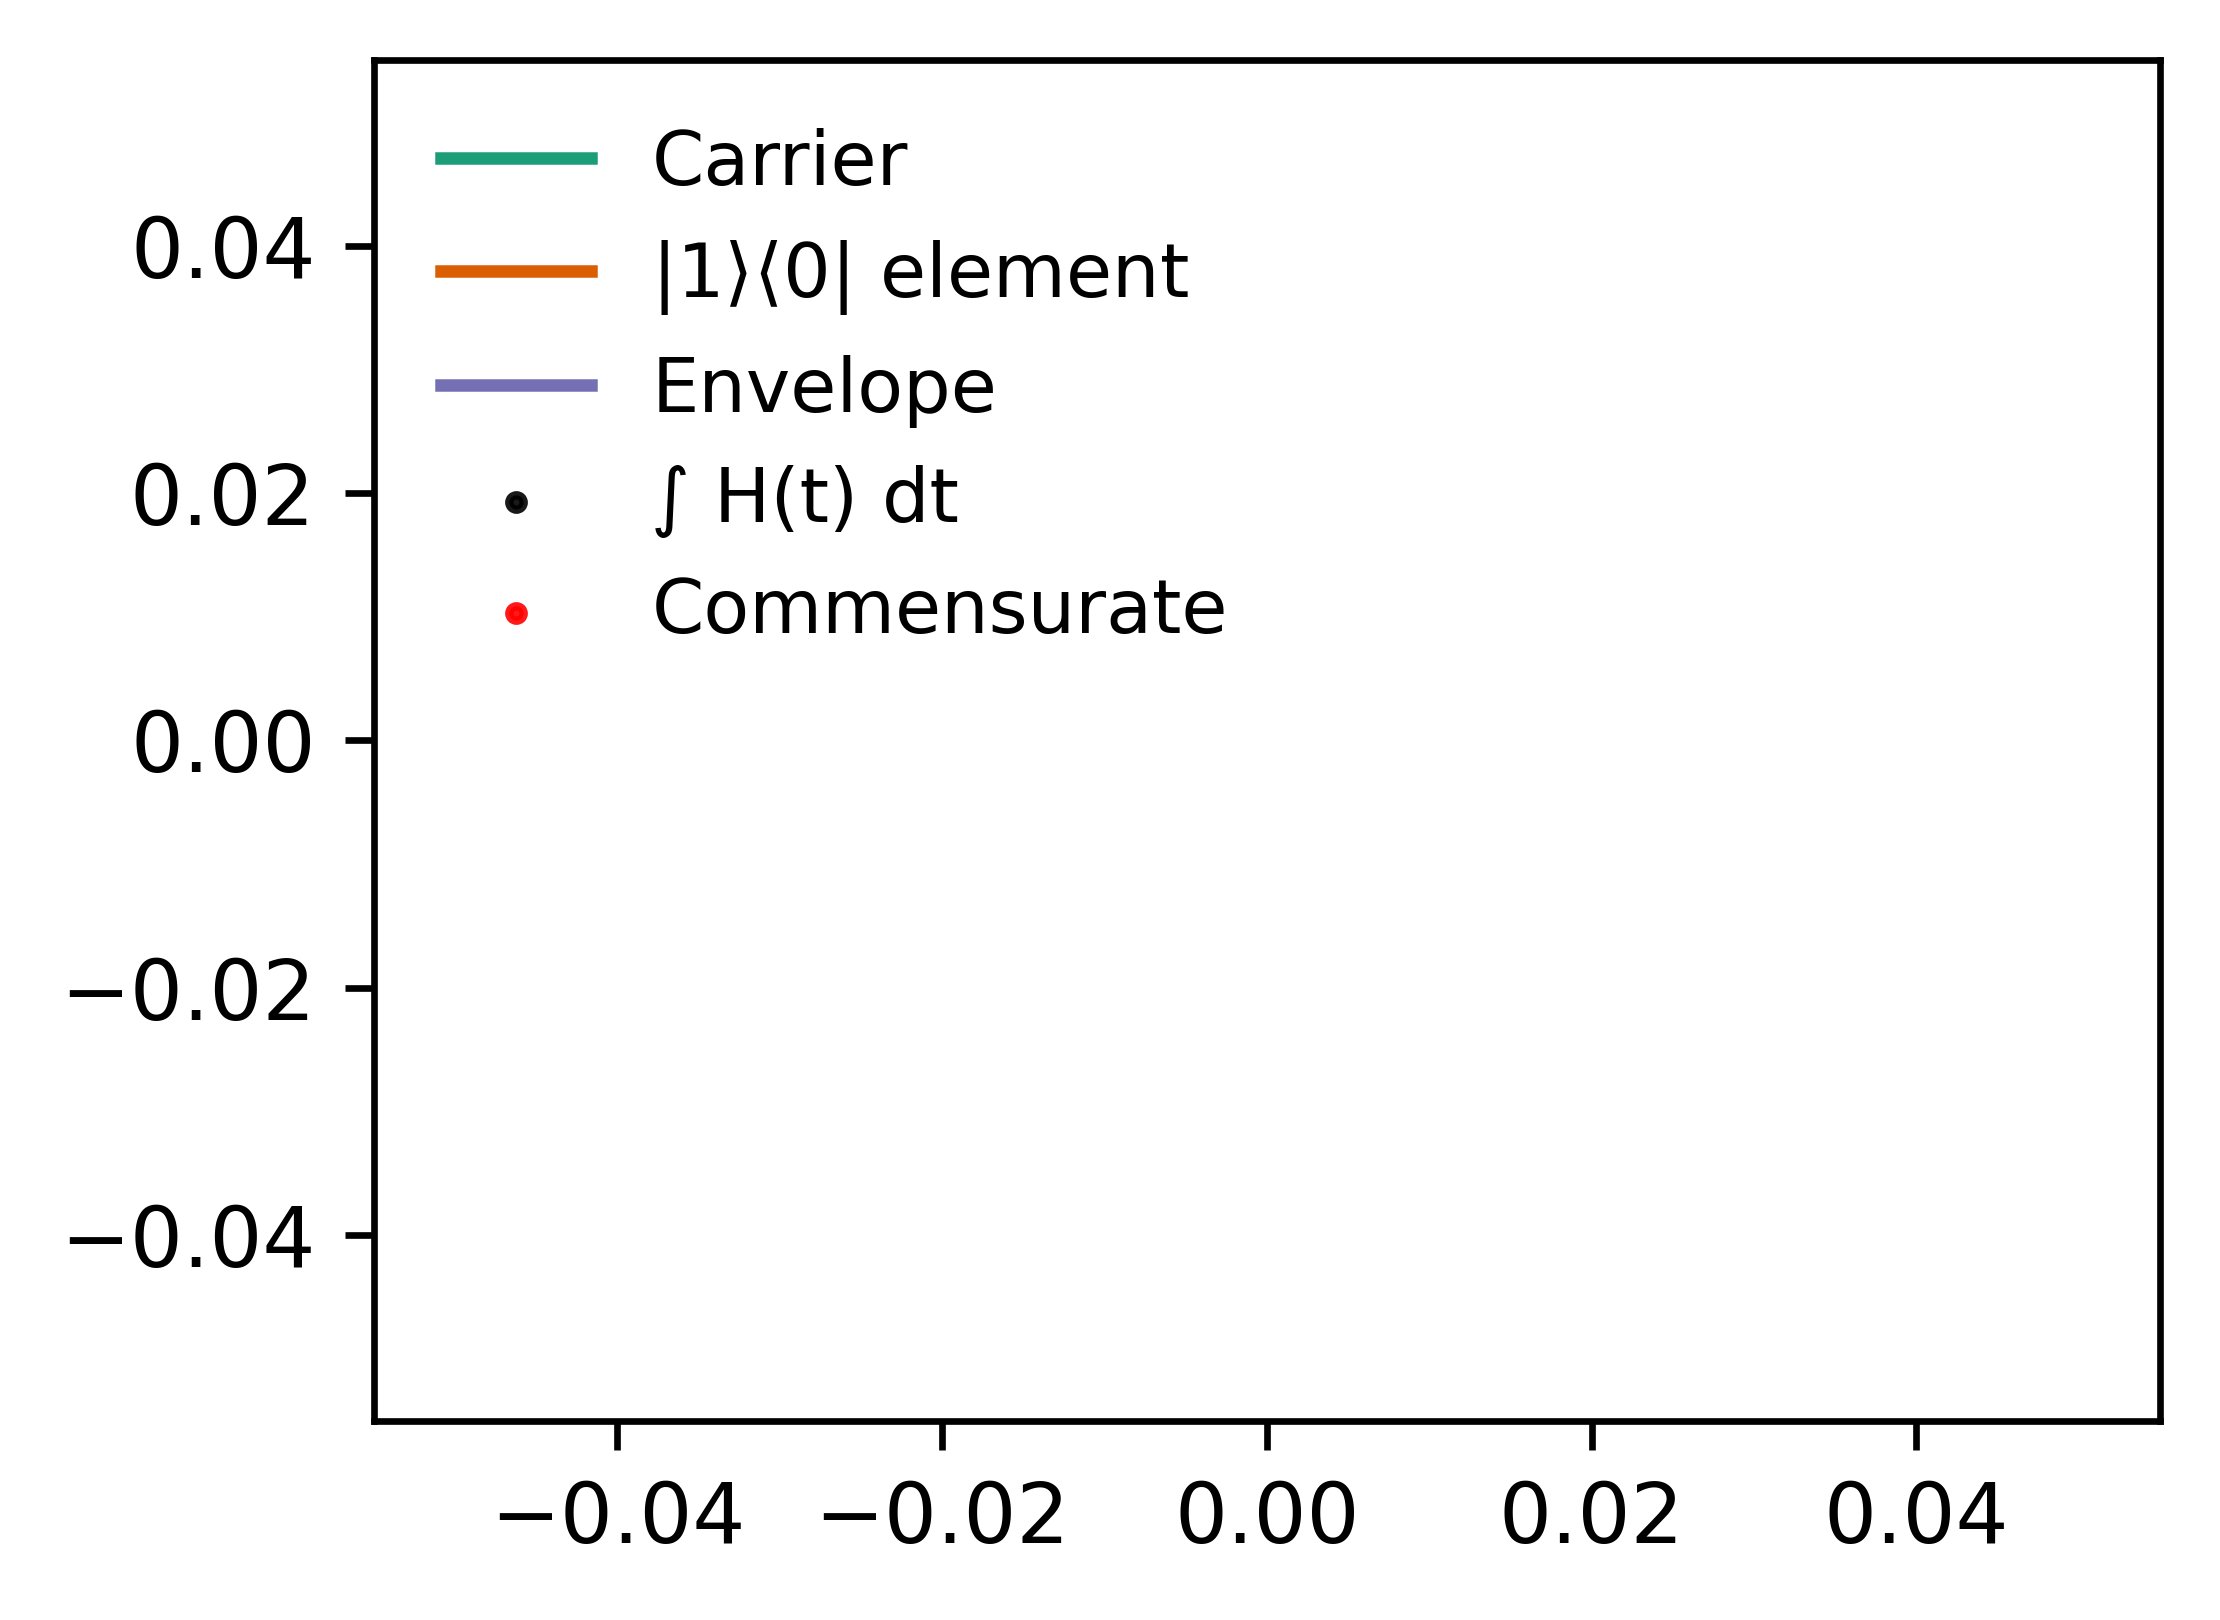

/tmp/ipykernel_46138/476331833.py:207: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_46138/476331833.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


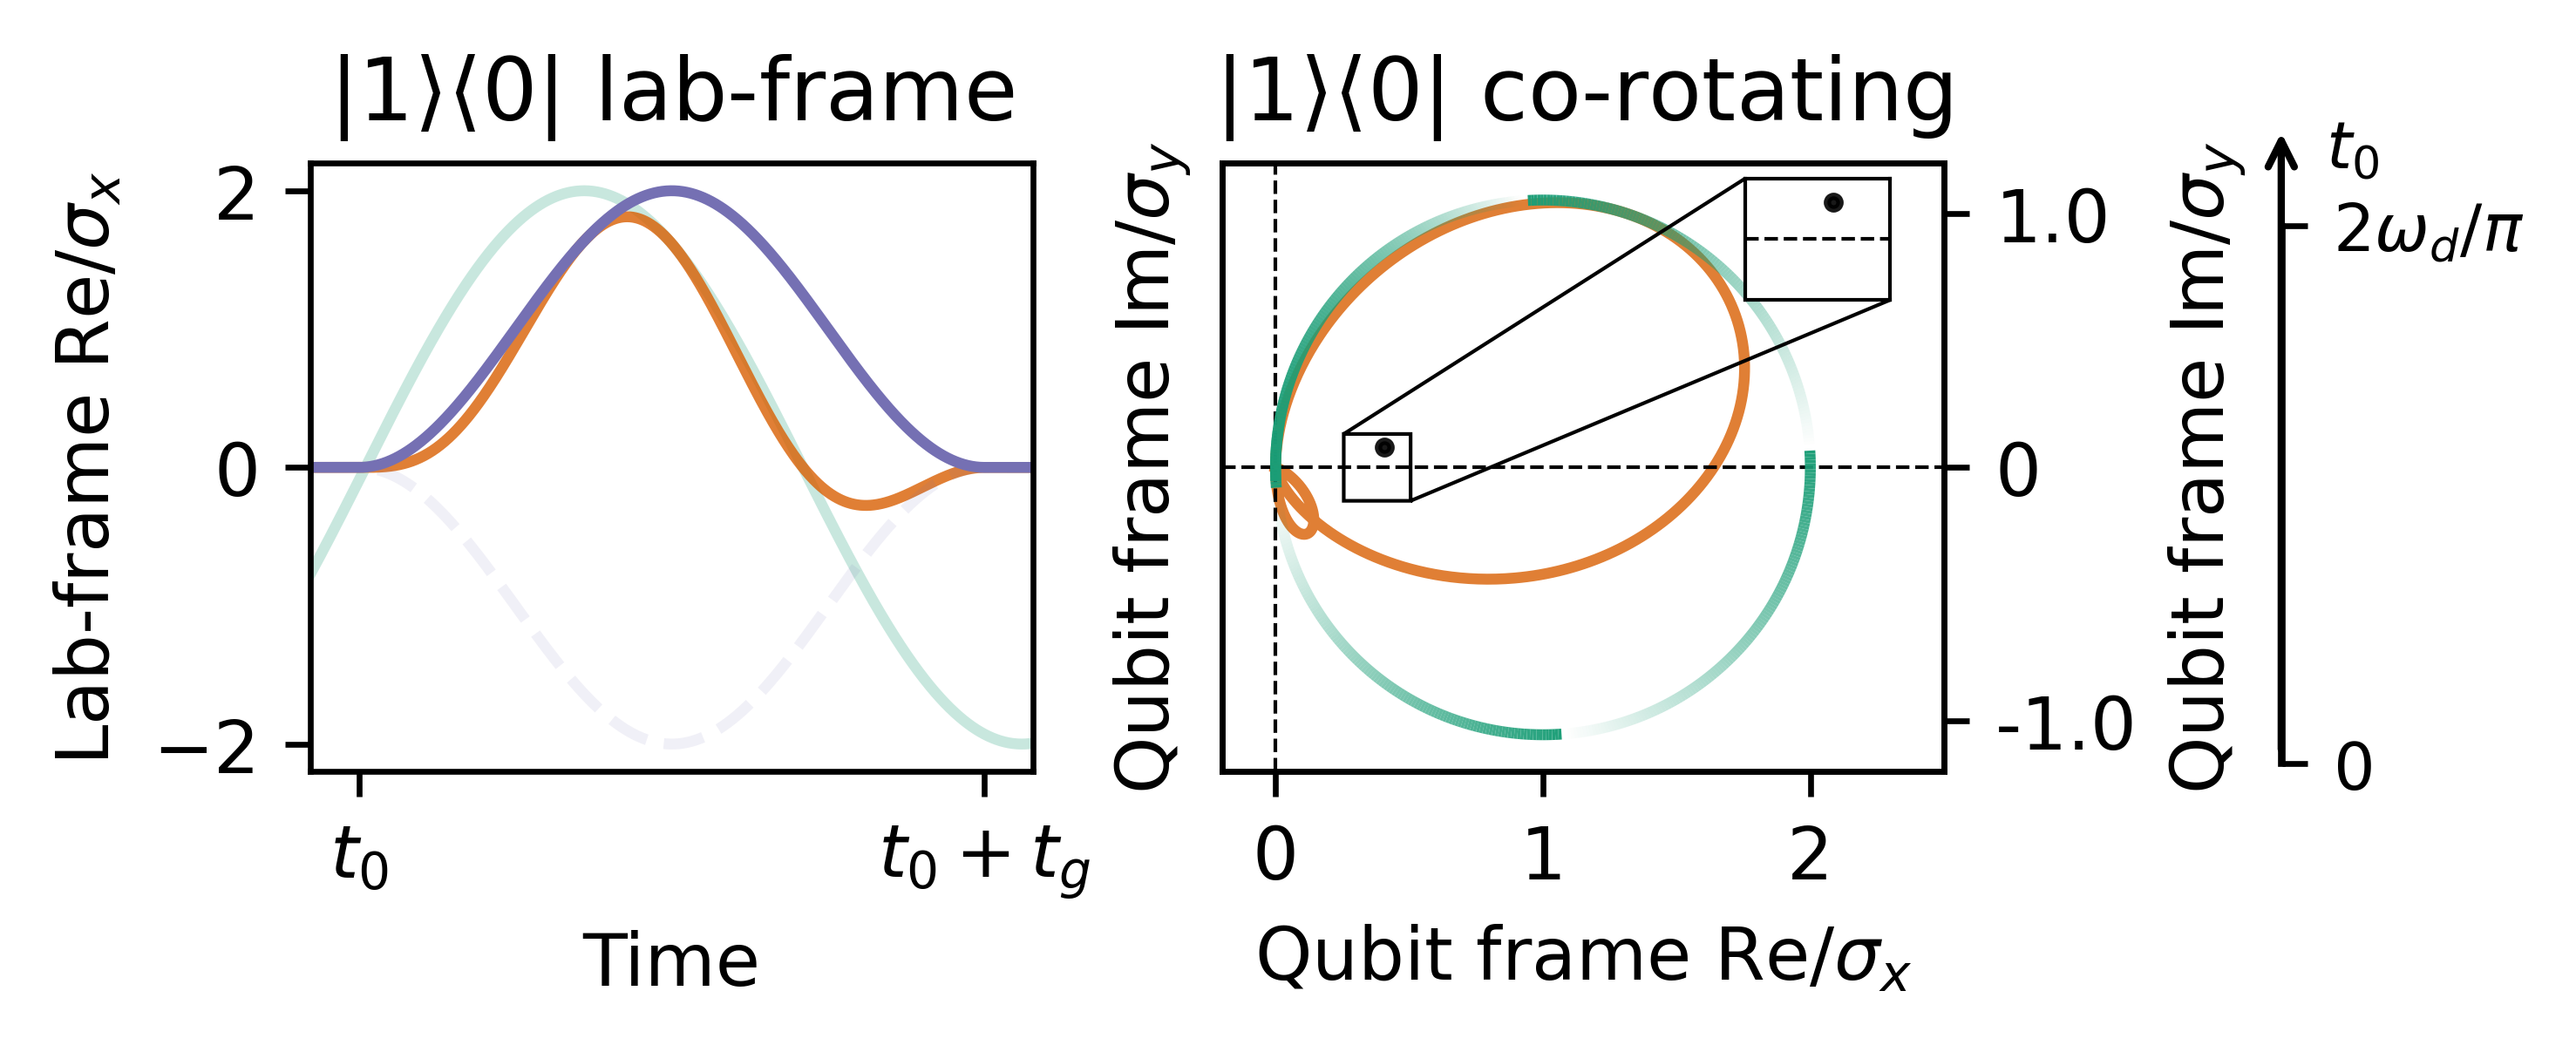

/tmp/ipykernel_46138/476331833.py:207: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_46138/476331833.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
/tmp/ipykernel_46138/476331833.py:207: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/tmp/ipykernel_46138/476331833.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.t

Video saved to matrix_entry.mp4


In [ ]:
#create a phase-space illustration of the |1><0| matrix element under a drive envelope
import numpy as np
import matplotlib.pyplot as plt
N = 500
omega_d = 1.1*np.pi
t_0s = np.linspace(0, 2*np.pi/omega_d, N,endpoint=False)

t0shift = 0.27
periodpoints = [t0shift + i * (np.pi/omega_d) for i in range(5)]
periodindex = [np.argmin(np.abs(t_0s - p)) for p in periodpoints]
periodindex = [indx for indx in periodindex if indx < N-1]
saved_t0markers = []
saved_meanmarkers = []
clrs = []
frame = 0
cs = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
#make seperate legend
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5),dpi=600)
plt.plot([], [], label='Carrier', color=cs[0], alpha=1, lw=1.5)
plt.plot([], [], label=r'$|1\rangle\langle0|$ element', color=cs[1], alpha=1, lw=1.5)
plt.plot([], [], label='Envelope', color=cs[2], alpha=1, lw=1.5)
plt.scatter([], [], label=r'∫ H(t) dt', color="black", s=3, alpha=0.9, zorder=10)
plt.scatter([], [], label=r'Commensurate', color="red", s=3, alpha=0.9, zorder=10)
plt.legend(loc='upper left', fontsize=9, frameon=False)
plt.tight_layout(pad=0,w_pad=0,h_pad=0)
plt.show()
for t_0 in t_0s:

    #for omega_d in np.linspace(0.5, 2.5, 20)*np.pi:
    #omega_d = 1.1*np.pi
    alpha = 0.8
    alpha2 = 0.9
    fig, ax = plt.subplots(1, 3, figsize=(4.9, 2.1),dpi=600, gridspec_kw={'width_ratios': [2,2,0.9]})
    ax[2].set_axis_off()  # Hide the third axis
    dt_0 = 0.7
    #zoomin
    e = 0.25
    a_x, a_y = 0.38, 0
    x1,x2 = a_x-e/2, a_x+e/2
    y1,y2 = a_y-e/2, a_y+e/2
    axins = ax[1].inset_axes(
        [0.725, 0.775, 0.2, 0.2],
        xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[],xticks=[], yticks=[],
    )
    ax[1].indicate_inset_zoom(axins, edgecolor="black", lw=0.5, alpha=1, ls='-')
    for k in axins.spines.keys():
        axins.spines[k].set_linewidth(0.5)


    t_0 += dt_0
    #t_0 = 0.1
    cs = [
        '#1b9e77',
        '#d95f02',
        '#7570b3'
    ]
    t_g = 1.3
    #omega_d = 1.4*np.pi
    X = np.linspace(-0.2, t_g+0.2, 1000, dtype=np.float64)
    period = np.pi/ omega_d
    period_idx = np.argmin(np.abs(X+0.2 - period))
    global_shift = np.argmin(np.abs(X))
    #envelope = np.piecewise(X, [False, True], [lambda x: 1-np.cos(2*np.pi*(x-t_0)/t_g), 0])
    def envelope_func(t):
        if t < 0 or t >  t_g:
            return 0
        else:
            return float(1 - np.cos(2 * np.pi * (t) / t_g))
    envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
    element = 1+ np.exp(2j * (omega_d * X+omega_d * t_0+omega_d*t_g/2))
    element_0 = np.cos(omega_d * X+omega_d * t_0+omega_d*t_g/2)
    eelem = element * envelope/2
    eelem_0 = 2*(element_0) * envelope
    
    if True:#np.isclose(t_0,dt_0):
        ax[0].plot(X, 2*element_0, label='Matrix Element', color=cs[0], alpha=0.3*alpha)
        #make arrows for bits of the envelope
        """s = 100
        for shift in range(0, len(X), period_idx//4):
            if shift < period_idx//4:
                continue
            bit_X = X[shift-s:shift-s+2]
            bit_Y = (2*element_0)[shift-s:shift-s+2].astype(np.float64)
            l = np.linalg.norm([bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0]])
            bit_X[1] = bit_X[0] + 0.05 * ((bit_X[1]-bit_X[0]) / l)
            bit_Y[1] = bit_Y[0] + 0.05 * ((bit_Y[1]-bit_Y[0]) / l)
            ax[0].arrow(bit_X[0], bit_Y[0], bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0],
                        head_width=0.04, head_length=0.1, fc=cs[0], ec=cs[0], lw=1.5, zorder=10,alpha=0.3*alpha,
                        length_includes_head=True)"""
    #two subplot, one for the time-axis envelope, and one for phase space
    
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel(rf'Lab-frame Re/$\sigma_x$')
    #ax[0].set_title('Real signal component vs. time')
    #ax[0].grid(True)
    
    ax[1].plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    ax[1].scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    if frame in periodindex:
        saved_meanmarkers.append((np.mean(np.real(eelem)), np.mean(np.imag(eelem))))
    for meanelement in saved_meanmarkers:
        ax[1].scatter(meanelement[0], meanelement[1], color="red", s=3, alpha=alpha2, zorder=10)
    ax[0].plot(X, np.real(eelem_0/2), label='Matrix Element', color=cs[1], alpha=alpha)
    axins.plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    axins.scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    for meanelement in saved_meanmarkers:
        axins.scatter(meanelement[0], meanelement[1], color="red", s=3, alpha=alpha2, zorder=10)
    axins.axhline(0, color='black', lw=0.5, ls='--')
    hex2rgb = lambda h: tuple(int(h[i:i+2], 16) for i in (1, 3, 5))
    clr = hex2rgb(cs[1])
    rgba = (clr[0]/255, clr[1]/255, clr[2]/255, alpha2)
    clrs.append(rgba)
    alpha *= 0.8
    alpha2 *= 0.9
    
    

    ax[0].plot(X, envelope, label='Drive Envelope', color=cs[2],alpha=1)
    ax[0].plot(X, -envelope, label='Drive Envelope', color=cs[2],alpha=0.1, ls='--')


        
    ax[1].set_xlabel('Qubit frame Re/$\sigma_x$')
    ax[1].set_ylabel(fr'Qubit frame Im/$\sigma_y$')
    ax[1].set_yticks([])
    ax[1].set_yticklabels([])
    ax[0].set_title(fr'$|1\rangle\langle0|$ lab-frame')
    ax[1].set_title(fr'$|1\rangle\langle0|$ co-rotating')
    #ax[1].grid(True)
    ax[1].set_aspect('equal', adjustable='box')
    ax[1].set_xlim(-0.2, 2.5)
    ax[1].set_ylim(-1.5, 1.5)
    #ax[0].legend()
    #ax[1].legend()
    ax[1].axhline(0, color='black', lw=0.5, ls='--')
    ax[1].axvline(0, color='black', lw=0.5, ls='--')
    from matplotlib import patches
    

    #h = input('Enter hex: ').lstrip('#')
    rgb = tuple(int(cs[0][i+1:i+3], 16) for i in (0, 2, 4))
    rgba_s = [
        (rgb[0]/255, rgb[1]/255, rgb[2]/255, x*4) for x in np.linspace(0, 1, len(element[:period_idx]))
    ]
    #ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=rgba_s)
    for shift in range(0, period_idx, period_idx//4):
        points = np.array([np.real(element[shift:shift+period_idx//4]), np.imag(element[shift:shift+period_idx//4])]).T
        segments = np.stack([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors=rgba_s[:-1], linewidths=1.5, label='Matrix Element')
        ax[1].add_collection(lc)
    """#cs_arr1 = 
    #ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=rgba_s)
    #use lineconnection to plot the element with the specified colors
    # Create line segments for phase space trajectory
    from matplotlib.collections import LineCollection
    for shift in range(0, period_idx, period_idx//4):
        points = np.array([np.real(element[shift:shift+period_idx//4]), np.imag(element[shift:shift+period_idx//4])]).T
        segments = np.stack([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors=rgba_s[:-1], linewidths=1.5, label='Matrix Element')
        ax[1].add_collection(lc)
        endbit = segments[:1]
        #ax[1].plot(endbit[:, 0], endbit[:, 1], lw=1.5, color="red")
        #use endbit to plot an arrow
        ax[1].arrow(endbit[0][0][0], endbit[0][0][1], endbit[0][1][0]-endbit[0][0][0], endbit[0][1][1]-endbit[0][0][1],
                    head_width=0.05, head_length=0.1, fc=cs[0],ec=cs[0], lw=1.5, zorder=10)
    

    #set a star for reference
    
    #ax[0].scatter(0.56, 1.8, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
    #ax[1].scatter(1.75, 0.4, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
    #ax[0].scatter(1.04, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
    #ax[1].scatter(0.15, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
    
    #use t_0s and clrs to construct a colormap and colorbar
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from matplotlib.colors import LinearSegmentedColormap
    trunc = len(t_0s)//1
    norm = Normalize(vmin=min(t_0s[:trunc]), vmax=max(t_0s[:trunc]))
    cmap = LinearSegmentedColormap.from_list('my_cmap', clrs[:trunc], N=len(t_0s[:trunc]))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # only needed for older versions of matplotlib
    cbarax = fig.add_axes([0.5, 0.08, 0.4, 0.18])  # [left, bottom, width, height]
    cbarax.set_axis_off()  # Hide the colorbar axis
    cbar = plt.colorbar(sm, ax=cbarax, orientation='vertical', pad=0.02, aspect=3)
    # Set the colorbar label and shift it upward by adjusting the position
    cbar.set_label(rf'$t_0$', fontsize=9, rotation=0, labelpad=0.0)
    cbar.ax.yaxis.set_label_coords(4, 0.7)  # (x, y): x > 1 moves label up and right
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks([0, 1.0])
    cbar.set_ticklabels([r'$\omega_d/\pi$', r'$0$'])
    cbar.ax.invert_yaxis()  # Invert the colorbar to match the plot

    plt.tight_layout()
    """
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from matplotlib.colors import LinearSegmentedColormap
    trunc = len(t_0s)//1
    norm = Normalize(vmin=min(t_0s), vmax=max(t_0s))
    #cmap = LinearSegmentedColormap.from_list('my_cmap', , N=len(t_0s))
    cmap = cm.get_cmap('viridis')
    #cmap = cmap(np.linspace(0, 1, trunc))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # only needed for older versions of matplotlib
    cbarax = fig.add_axes([0.56, 0.28, 0.4, 0.49])  # [left, bottom, width, height]
    cbarax.set_axis_off()  # Hide the colorbar axis
    cbar = plt.colorbar(sm, ax=cbarax, orientation='vertical', pad=0.02, aspect=300)
    # Set the colorbar label and shift it upward by adjusting the position
    cbar.set_label(rf'$t_0$', fontsize=9, rotation=0, labelpad=0.0)
    cbar.ax.yaxis.set_label_coords(40, 1.2)  # (x, y): x > 1 moves label up and right
    #set an arrow as an extension for the colorbar axis
    cbarax.annotate('', xy=(1.025, 1.2), xytext=(1.025, 0),
                    arrowprops=dict(arrowstyle='->', lw=1, color='black'),
                    xycoords='axes fraction', textcoords='axes fraction',
                    fontsize=9, ha='center', va='center')
    cbarax.set_xlim(0, 1.0)  # Set x limits to allow space for the arrow
    #cbarax.scatter([1.0], [0.5], color='black', s=10, label='Extension', zorder=10)
    def t02cbar(t_0):
        return t_0/np.pi*1.745-0.43
    cbarax.annotate('-', xy=(1, t02cbar(t_0)), xytext=(1.025, t02cbar(t_0)))
    if frame in periodindex:
        saved_t0markers.append(t_0)
    for st0 in saved_t0markers:
        cbarax.annotate('-', xy=(1, t02cbar(st0)), xytext=(1.025, t02cbar(st0)),color='red')
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks([0, 2.0])
    cbar.set_ticklabels([r'$2\omega_d/\pi$', r'$0$'])
    #cbar.set_clim(0, 1.1)
    cbar.ax.invert_yaxis()  # Invert the colorbar to match the plot
    plt.tight_layout()
    
    ax[0].set_xlim(-0.1,t_g+0.1)
    ax[0].set_xticks([0, t_g])
    ax[0].set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
    axt = ax[1].twinx()
    axt.set_ylabel(rf'Qubit frame Im/$\sigma_y$')
    axt.set_ylim(-1.2, 1.2)
    axt.set_yticks([-1.0,0,1.0])
    axt.set_yticklabels(['-1.0', '0', '1.0'])

    plt.savefig(f'temp/phase_space_matrix_element_{frame}.png')
    if frame == 0:
        plt.show()
    else:
        plt.close(fig)
    frame += 1

def frames_to_mp4(frames, output_path, fps=24, codec='libx264', quality=8):
    """
    Convert a list of image frames (numpy arrays) into an MP4 video.

    Parameters:
        frames (list of np.ndarray): List of image frames (all same size and dtype).
        output_path (str): Path to the output MP4 file.
        fps (int): Frames per second for the output video.
        codec (str): Video codec (default 'libx264').
        quality (int): Quality setting (higher is better quality, 0–10 for imageio; default 8).
    """
    if not frames:
        raise ValueError("The frame list is empty.")

    height, width = frames[0].shape[:2]
    for i, frame in enumerate(frames):
        if frame.shape[:2] != (height, width):
            raise ValueError(f"Frame {i} has a different size than the first frame.")

    writer = imageio.get_writer(output_path, fps=fps, codec=codec, quality=quality)

    for frame in frames:
        writer.append_data(frame)

    writer.close()
    print(f"Video saved to {output_path}")

frames = []
import imageio

for frame in range(N):
    img = imageio.imread(f'temp/phase_space_matrix_element_{frame}.png')
    frames.append(img)

frames_to_mp4(frames, 'matrix_entry.mp4', fps=8*N//100, codec='libx264', quality=8)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Optimizing qubitoptimm_None,1,None,3.141592653589793,1,2,18.84955592153876,2000,50
Found cached optimization, loading...
Loaded
Optimized: [1.02889161 3.00645822]
Solving eigvals for 1.0288916110992425,1,3.0064582228660752,3.141592653589793,18.84955592153876,2000,50,3,__
Found cached eigvals, loading...
Solving eigvals for 1.0288916110992425,1,3.0064582228660752,3.141592653589793,18.84955592153876,3000,50,3,__
Found cached eigvals, loading...
[0.0005909664566791465, inf]


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}
  % Total    % Received % Xferd

Solving eigvals for 1.0288916110992425,1,3.0064582228660752,3.141592653589793,20.420352248333657,3000,50,3,__
Found cached eigvals, loading...
[0.0005909664566791465, 4.154762128412888e-06]
Solving eigvals for 1.0288916110992425,1,3.0064582228660752,3.141592653589793,20.420352248333657,4000,50,3,__


100    22  100    22    0     0     72      0 --:--:-- --:--:-- --:--:--    72
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    22  100    22    0     0     79      0 --:--:-- --:--:-- --:--:--    78


Waiting 0.5088774012171792 seconds for GPU
Found cached eigvals, loading...
Solving eigvals for 1.0288916110992425,1,3.0064582228660752,3.141592653589793,20.420352248333657,3000,50,3,__
Found cached eigvals, loading...


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}
/home/ubuntu-compute/miniconda3

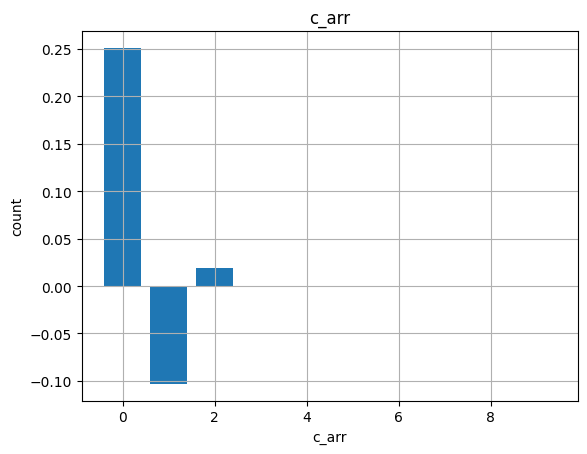

Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 1.0503671646938597
[1.+0.j 0.+0.j]
Testing at t0 = 2.1007343293877194
[1.+0.j 0.+0.j]
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST_nooptim: (0.9916570560241551-1.1564823173178713e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST_nooptim: (0.9952442038764807-2.2695965477363224e-17j)
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST_nooptim: (0.9952452817020587-1.922651852540961e-17j)


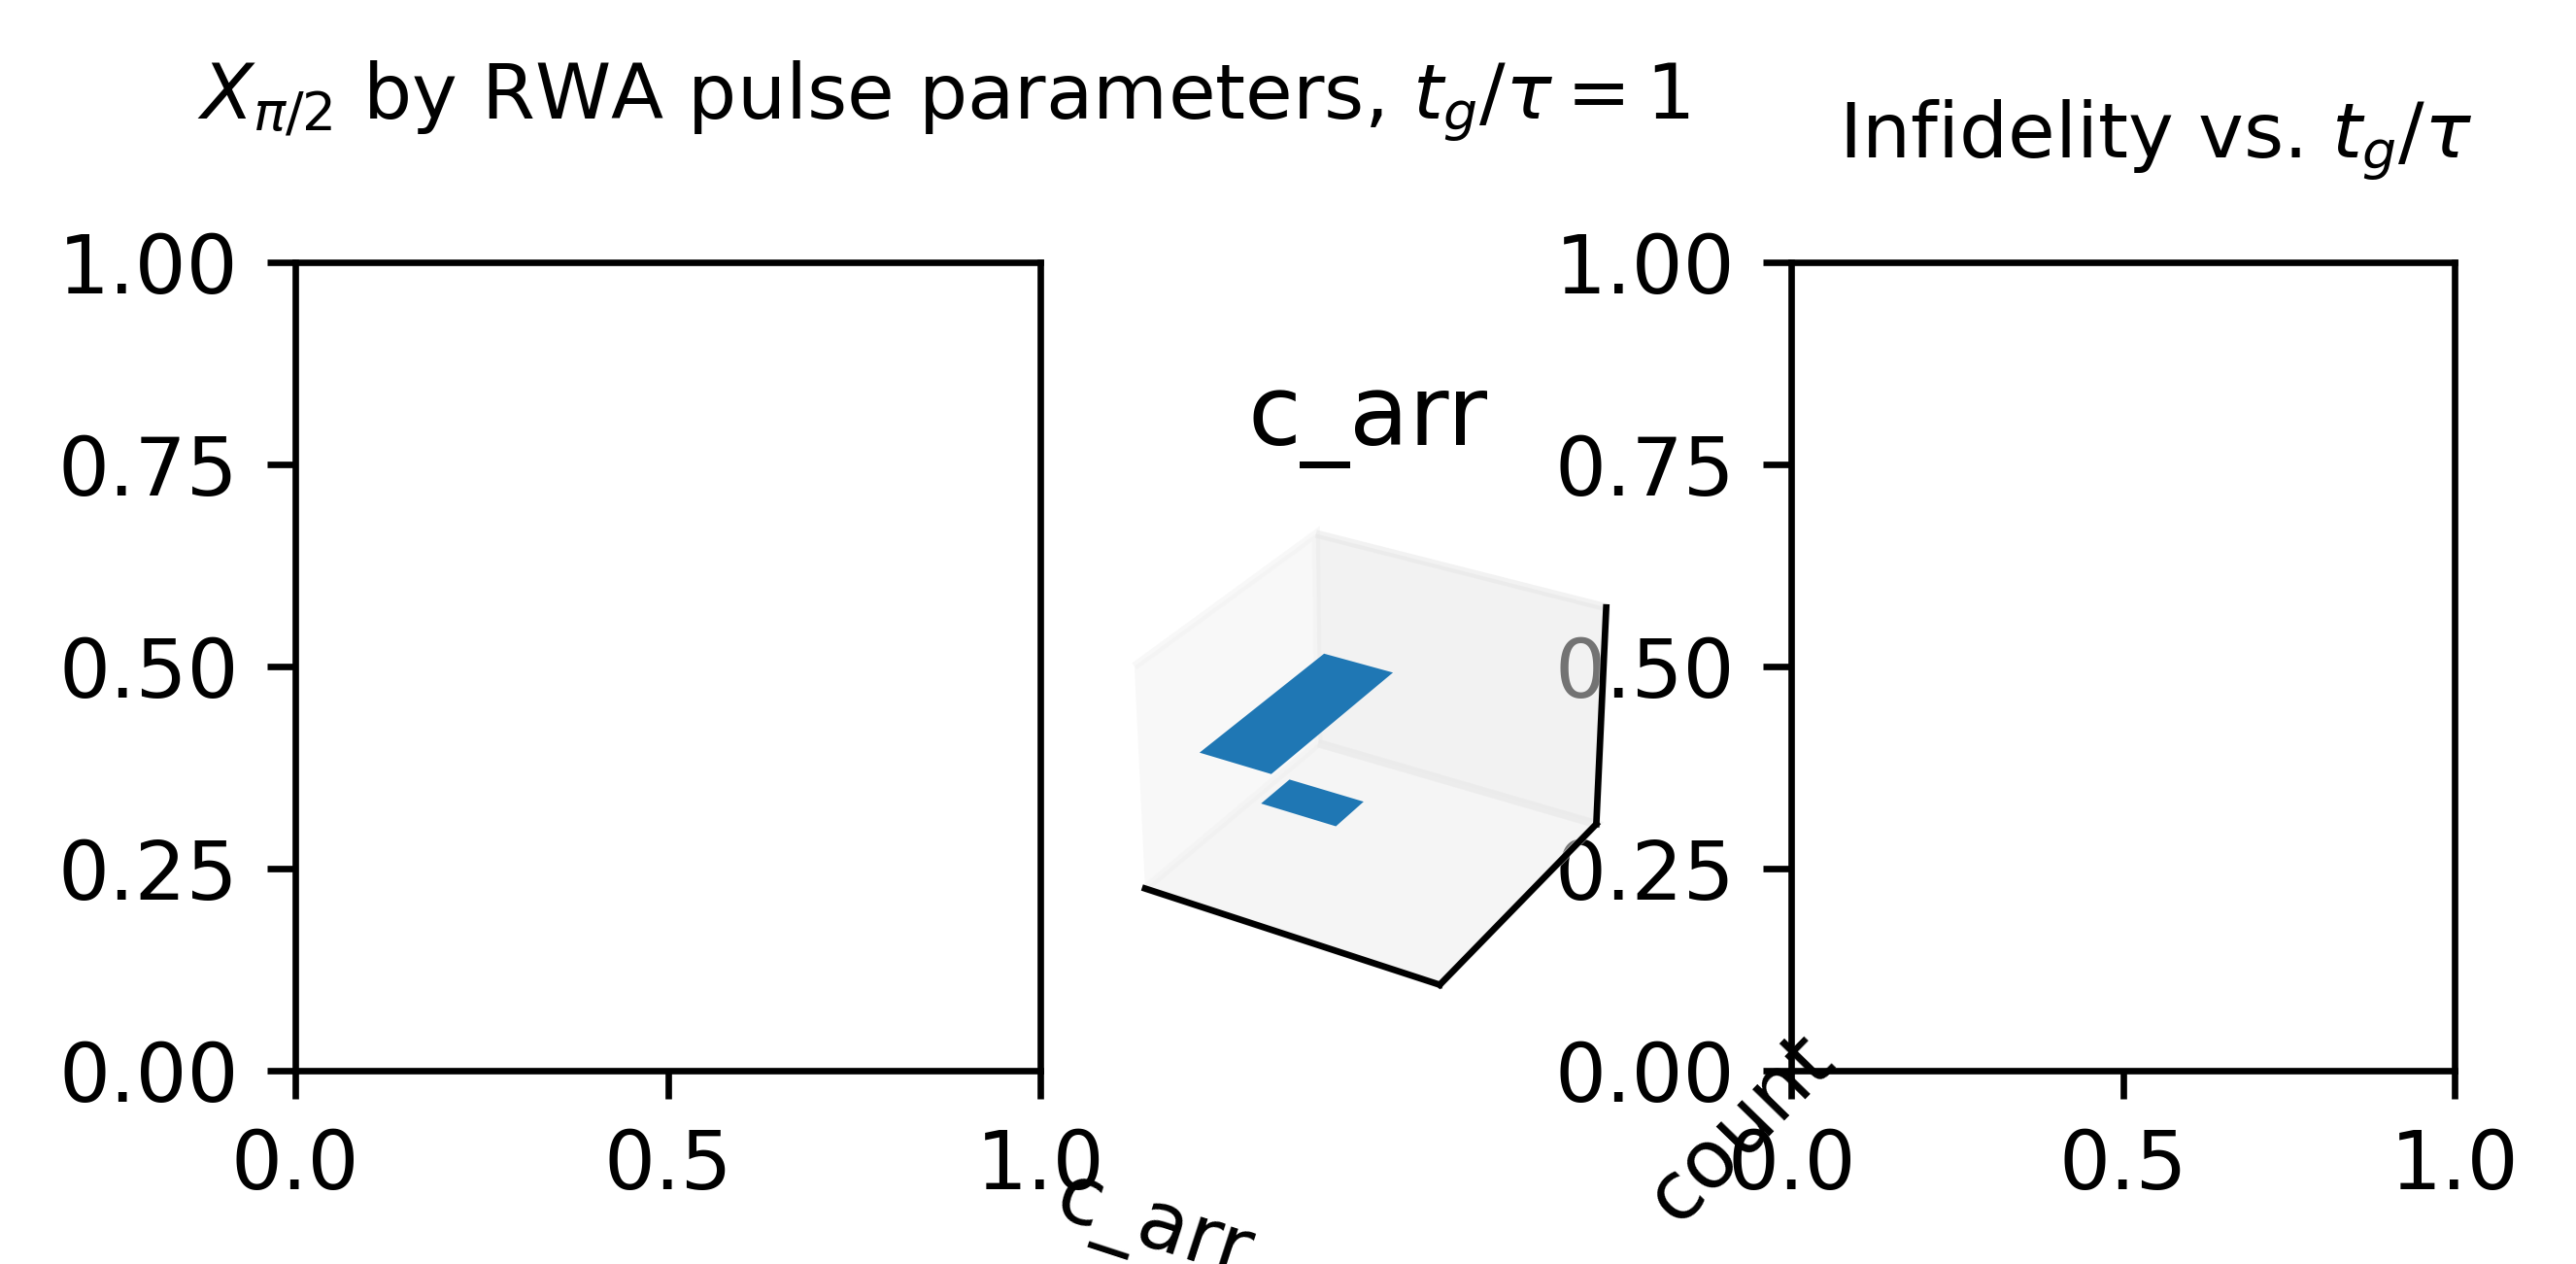

Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 1.0503671646938597
[1.+0.j 0.+0.j]
Testing at t0 = 2.1007343293877194
[1.+0.j 0.+0.j]
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST-MAGNUS: (0.9993459346448136+7.806255641895632e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST-MAGNUS: (0.9995840689873732+6.292290127796977e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000554527842587_inf_inf with FAST-MAGNUS: (0.999584069924657-5.082197683525802e-18j)


  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_1834989/2894959763.py:43: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_1834989/2894959763.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func2(t) for t in X], dtype=np.float64)
100%|██████████| 1000/1000 [00:01<00:00, 639.11it/s]
/tmp/ipykernel_1834989/2894959763.py:157: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
/tmp/ipykernel_1834989/2894959763.py:164: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope2 = np.array([envelope_func2(t) for t in X], dtype=np.float64)


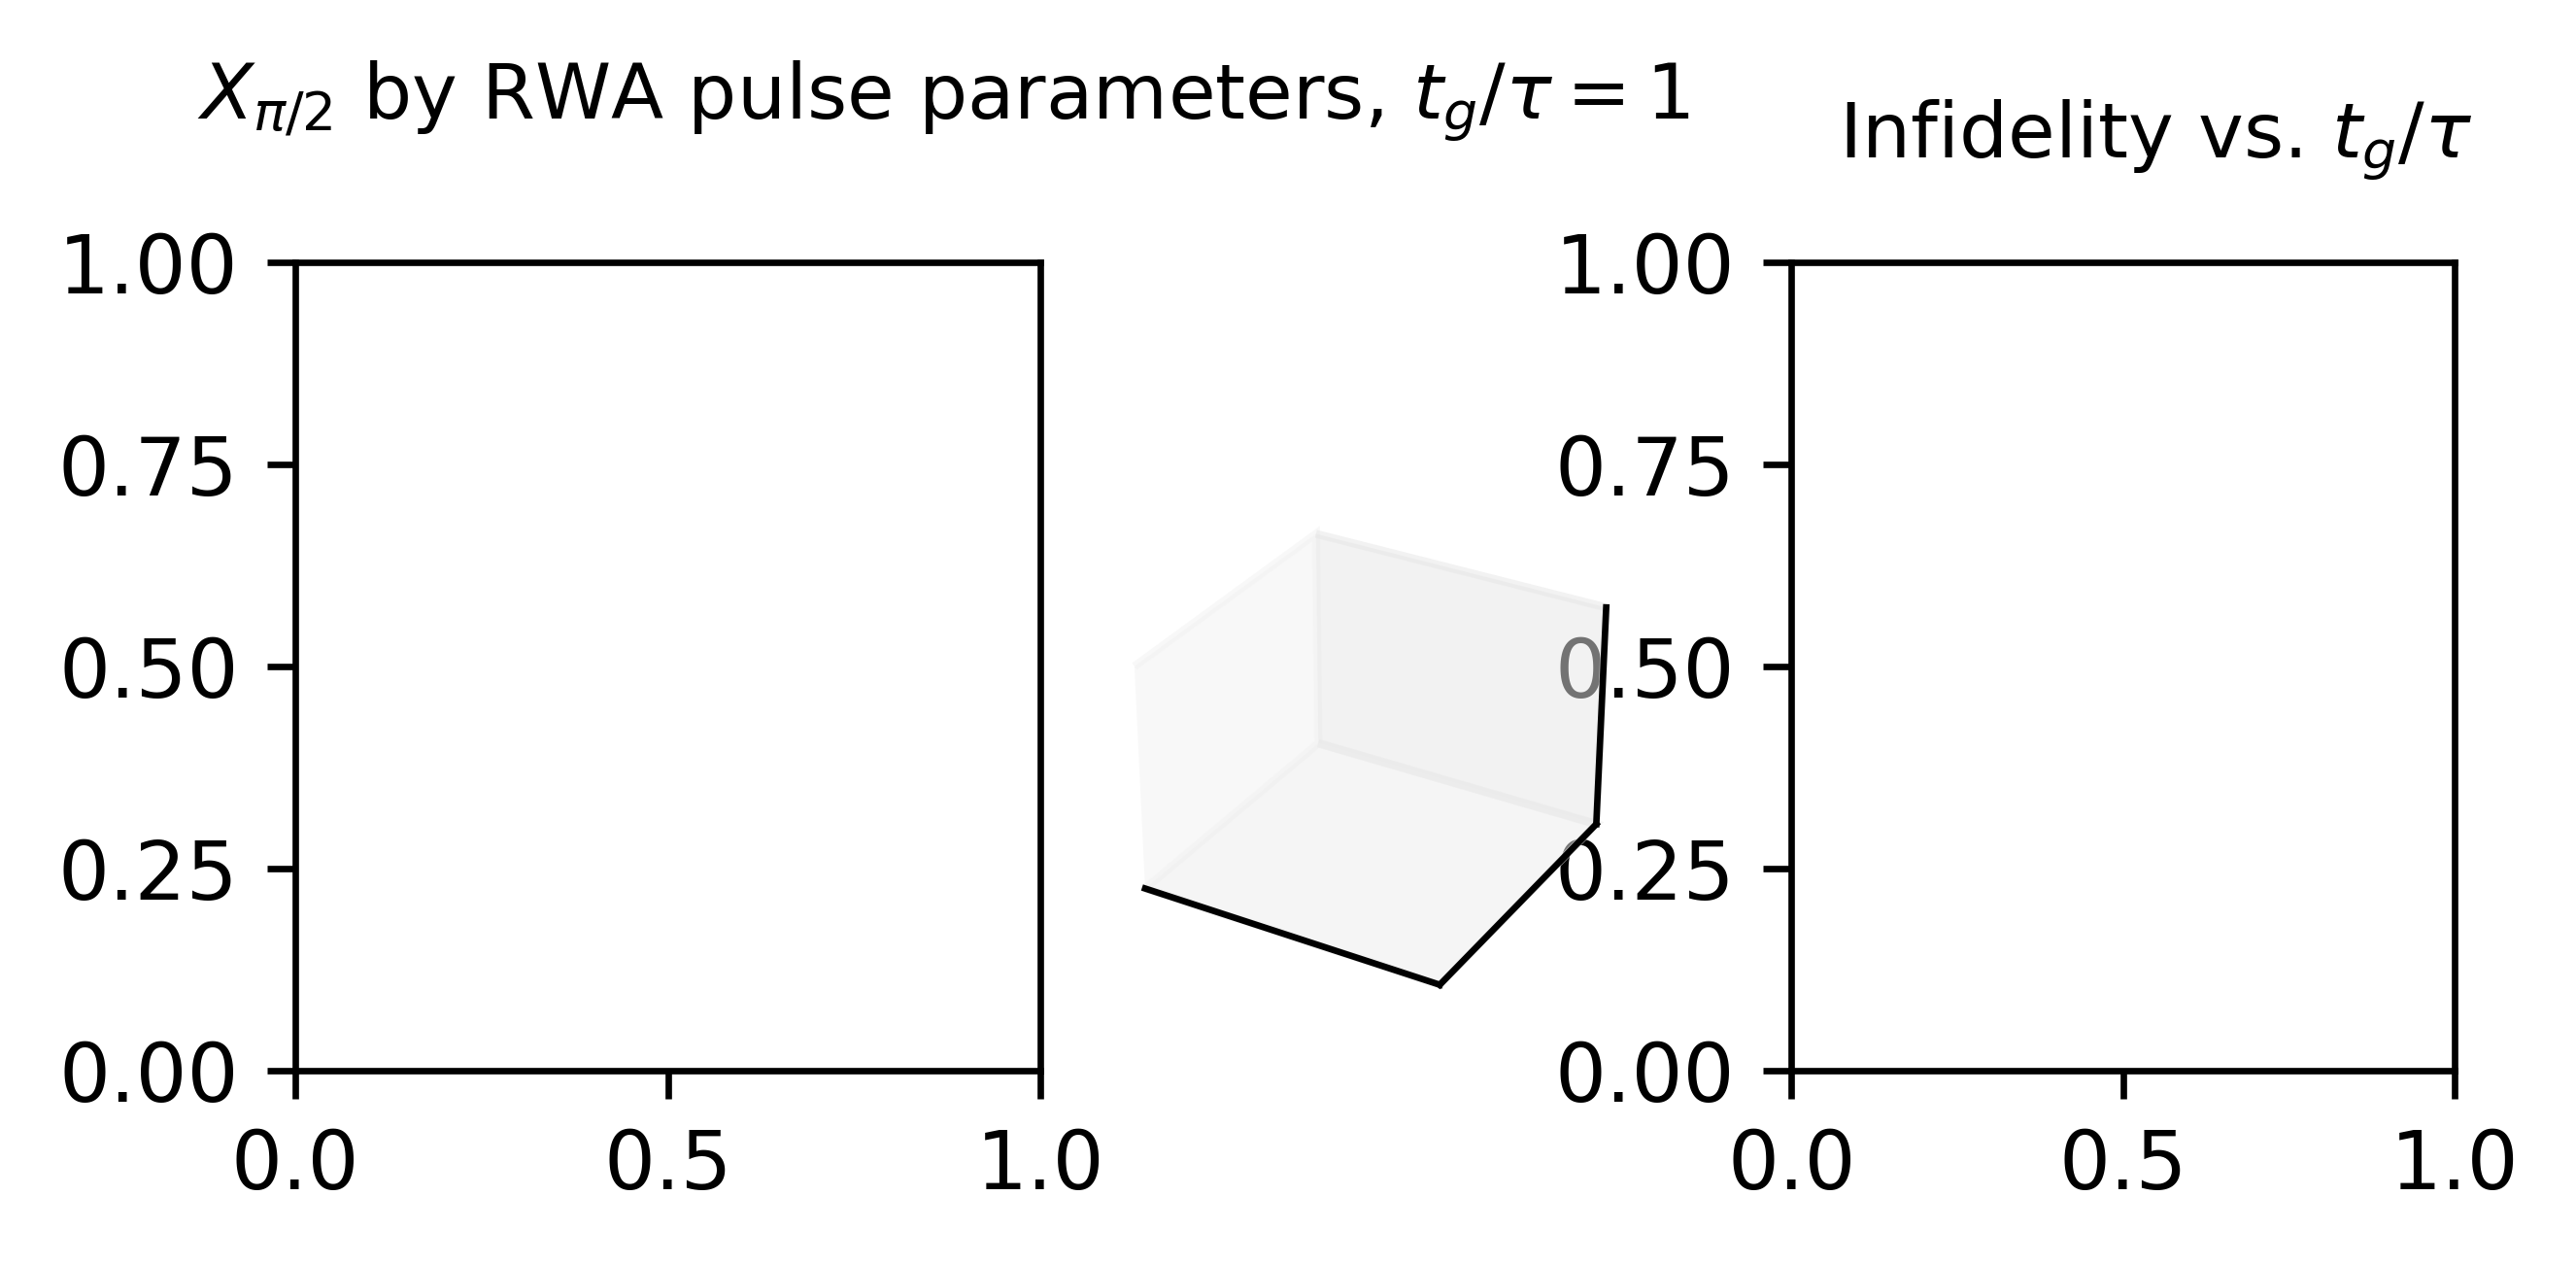

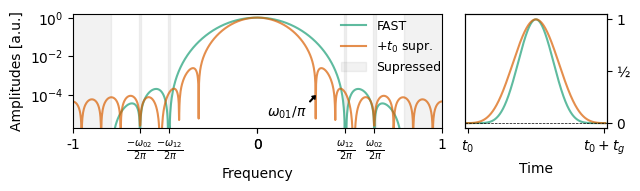

In [10]:
#DRAG spectra plot
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import numpy as np
import utils.gate_params as gp
import utils.eval_functions as ef
from utils.eval_functions import AdaptiveLearner
Lambda = 0.9
#learner = AdaptiveLearner([], [None, 1, None, 1, 2, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
#learner = AdaptiveLearner([], [None, 1, None, 1, 0.9, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
Lambda = 1.5
learner = AdaptiveLearner([], [None, 1, None, 1, 2, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
#learner = AdaptiveLearner([], [None, 1, None, 0.1, 0.2, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
qubits_2_eval = learner.get_next_dp(N=1)
for i in range(len(qubits_2_eval)):
    qubits_2_eval[i]["Ec_IC"] = 0.4
    qubits_2_eval[i]["El_IC"] = 1
    qubits_2_eval[i]["Ej_IC"] = 1.3
gate = gp.get_gate_params("FAST_nooptim")
gate2 = gp.get_gate_params("FAST-MAGNUS")
#gate = gp.get_gate_params("FAST-DRAG")
#gate2 = gp.get_gate_params("FAST-MAGNUS-DRAG")
t_0 = 0.0
qubit, gate = ef.calib_gate((qubits_2_eval[0], gate))
t_g = qubit["t_g"]
_, gate2 = ef.calib_gate((qubits_2_eval[0], gate2))
coffs = gate.envelope_coffs
coffs2 = gate2.envelope_coffs
def envelope_func(t):
    if t < 0 or t >  t_g:
        return 0
    else:
        return sum([coffs[i] * (1-np.cos(2 * np.pi * (i+1) * (t-t_0) / t_g)) for i in range(len(coffs))])
def envelope_func2(t):
    if t < 0 or t >  t_g:
        return 0
    else:
        return sum([coffs2[i] * (1-np.cos(2 * np.pi * (i+1) * (t-t_0) / t_g)) for i in range(len(coffs2))])
#do a fourier transform of this envelope
def fourier_transform(f):
    X = np.linspace(0, t_g, 200)
    envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
    wave = np.exp(2j * np.pi * f * X)
    return np.trapz(envelope * wave, X)
def fourier_transform2(f):
    X = np.linspace(0, t_g, 400)
    envelope = np.array([envelope_func2(t) for t in X], dtype=np.float64)
    wave = np.exp(2j * np.pi * f * X)
    return np.trapz(envelope * wave, X)
axins = None
def plot_DRAG_spectra(frequencies, ax):
    global axins
    from tqdm import tqdm
    spectra = [fourier_transform(f) for f in tqdm(frequencies)]
    spectra2 = [fourier_transform2(f) for f in tqdm(frequencies)]
    spectra /= np.max(np.abs(spectra))
    spectra2 /= np.max(np.abs(spectra2))
    ax.plot(frequencies, np.abs(spectra), label='FAST', color='#1b9e77', alpha=0.7)
    #ax.plot(frequencies, np.abs(spectra), color='#1b9e77', alpha=0.7)
    #ax.plot(frequencies, np.abs(spectra2), label='FAST-Magnus', color='#d95f02', alpha=0.7)
    ax.plot(frequencies, np.abs(spectra2), label=r'$+t_0$ supr.', color='#d95f02', alpha=0.7)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Amplitudes [a.u.]')
    #make a zoomed-in frame
    x1, x2 = -0.5, -0.46
    y1, y2 = 6e-7, 1e-5
    """
    axins = ax.inset_axes(
        [0.05, 0.6, 0.20, 0.38],
        xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[],xticks=[], yticks=[],
    )
    #make ackground transparent
    #axins.patch.set_alpha(0.0)
    axins.plot(frequencies, np.abs(spectra), color='#1b9e77', alpha=0.7)
    axins.plot(frequencies, np.abs(spectra2), color='#d95f02', alpha=0.7)
    axins.set_yscale('log')
    ax.indicate_inset_zoom(axins, edgecolor="black", lw=0.5, alpha=1, ls='-')
    axins.set_yticks([])
    axins.set_yticklabels([])
    axins.set_xticks([])
    axins.set_xticklabels([])
    axins.set_yticks([], minor=True)
    axins.set_xticks([], minor=True)
    #ax.set_title('FAST spectrum')
    #ax.grid(True)"""
    return spectra, spectra2
    
#forbidden 
forbidden = gate.forbidden_intervals
import sympy as sp
omega_01 = qubit["omega_01_actual"]
omega_12 = qubit["omega_12_actual"]
#fig, ax = plt.subplots(figsize=(5, 2.5))
fig, axs = plt.subplots(1,2, figsize=(6.5, 2), width_ratios=[2.6, 1])
ax = axs[0]
ax2 = axs[1]



r = 1
frequencies = np.linspace(-r, r, 1000)  # Frequency range for the spectrum
s1,s2 = plot_DRAG_spectra(frequencies, ax)
xticks = [0]
xlabels = [r'$0$']

for i in range(len(forbidden)):
    forbidden[i] = list(forbidden[i])
    for j in range(len(forbidden[i])):
        if isinstance(forbidden[i][j], sp.Basic):
            forbidden[i][j] = forbidden[i][j].subs(sp.symbols('omega_{01}'), omega_01)
            forbidden[i][j] = forbidden[i][j].subs(sp.symbols('omega_{12}'), omega_12)
            forbidden[i][j] = float(forbidden[i][j])
        if np.isinf(np.abs(forbidden[i][j])):
            forbidden[i][j] = 1000000
    #plot these as grey shaded regions
    #ax.axvspan(forbidden[i][0], forbidden[i][1], color='grey', alpha=0.1, label='Forbidden Region' if i == 0 else "")
    x1 = forbidden[i][0]
    x2 = forbidden[i][1]
    y1= 1e-8
    y2 = 1000
    ax.fill_betweenx([y1, y2], x1, x2, color='grey', alpha=0.1, label='Supressed' if i == 0 else "")
    ax.fill_betweenx([y1, y2], -x1, -x2, color='grey', alpha=0.1)
    #axins.fill_betweenx([y1, y2], x1, x2, color='grey', alpha=0.1)
    #!axins.fill_betweenx([y1, y2], -x1, -x2, color='grey', alpha=0.1)
    avg = (x1 + x2) / 2
    if avg < 100000:
        xticks.append(avg)
        xticks.append(-avg)
    else:
        pass
        #xticks.append(x1)
        #xticks.append(-x1)

xlabels += [r'$\frac{\omega_{{02}}}{2\pi}$', r'$\frac{-\omega_{{02}}}{2\pi}$']

xlabels += [r'$\frac{\omega_{{12}}}{2\pi}$', r'$\frac{-\omega_{{12}}}{2\pi}$']
#xlabels += [r'$\frac{\omega_{{01}}+\omega_{{02}}}{2\pi}$', r'$-\frac{\omega_{{01}}+\omega_{{02}}}{2\pi}$']

#ax1 = ax.twiny()
#ax1.set_xticks(xticks)
#ax1.set_xticklabels(xlabels)
#ax1.set_xlim(-1.1, 1.1)
lgnd = ax.legend(fontsize=9, loc='upper right', frameon=False, bbox_to_anchor=(1.03,1.05))
#!lgnd.legend_handles[2]._width = 15
#!lgnd.legend_handles[2]._x0 = 6
#!lgnd.legend_handles[1]._xorig[2] = 21
#!lgnd.legend_handles[1]._xorig[0] = 6
#!lgnd.legend_handles[0]._xorig[2] = 21
#!lgnd.legend_handles[0]._xorig[0] = 6
#!ax.set_yscale('log')
ax.set_ylim(5e-7, 1.3)
ax.set_xlim(-r,r)

#plot the time domain of the envelope
X = np.linspace(-0.1, t_g+0.1, 1000)
envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
envelope /= np.max(np.abs(envelope))  # Normalize the envelope
ax2.plot(X, envelope, label='Envelope', color='#1b9e77', alpha=0.7)
for i in range(5):
    cosfunc = lambda t, n : 1 - np.cos(2 * np.pi * (n+1) * (t-t_0) / t_g)
    env = np.array([cosfunc(t, i) for t in X], dtype=np.float64)
    #!ax2.plot(X, env/2/(i+1), color='#1b9e77', alpha=0.3, lw=0.5)
envelope2 = np.array([envelope_func2(t) for t in X], dtype=np.float64)
envelope2 /= np.max(np.abs(envelope2))  # Normalize the envelope
ax2.plot(X, envelope2, label='Envelope (Dyson)', color='#d95f02', alpha=0.7)
ax2.set_xlabel('Time')
#ax2.set_ylabel('Amplitude')
#ax2.set_title('Envelope in time domain')
ax2.set_xlim(-0.2, t_g+0.2)
#ax2.axhline(0, color='black', lw=0.5, ls='--')
#ax2.axvline(0, color='black', lw=0.5, ls='--')
ax2.set_xticks([0, t_g])
ax2.set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
ax2.set_yticks([])
ax2.set_yticklabels([])
#ax2.legend(fontsize=9, loc='upper right', frameon=False, bbox_to_anchor=(1.03,1.05))
ax2.axhline(0, color='black', lw=0.5, ls='--')
#ax2.set_aspect('equal', adjustable='box')  
ax3 = ax2.twinx()
ax3.set_yticks([-1, 0, 1])
ax3.set_yticklabels(['0', '½', '1'])
ax3.set_ylim(-1.1, 1.1)
#ax3.set_ylabel('Normalized Amplitude')

annot_x = omega_01/np.pi
indx_cord = np.argmin(np.abs(frequencies - annot_x))
annot_y = 1e-4
ax.annotate(f'$\omega_{{01}}/\pi$',
    xy=(annot_x, annot_y), 
    xytext=(omega_01/np.pi*2, 0.1), 
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=3, headlength=2),
    horizontalalignment='right')

xticks += [-1,0, 1]
xlabels += ['-1', '0', '1']
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

ax.set_yscale('log')
ax.set_ylim(2e-6,1.5)



#raise UserWarning("Make the markings for the supressed regions of the spectra")
plt.tight_layout()
plt.savefig('FAST_spectrum.pdf')
plt.show()

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
coffs /= np.sum(coffs**2)
coffs *= 1
currentEnv = np.zeros(100,dtype=np.float64)
T = np.linspace(t_0, t_g+t_0, 100)
cnt = 0
for i,c in tqdm(enumerate(coffs)):
    N = 3
    storyboard = {
        "wait_e": list(range(N)),
        "wait_c": list(range(N)),
        "componentdisplay": list(range(N)),
        "transfer2envelope": list(range(N)),
    }
    order = ['wait_e', 'componentdisplay', 'wait_c', 'wait_c', 'wait_c', 'wait_c', 'transfer2envelope', 'wait_e']
    component = 0.1*(1 - np.cos(2 * np.pi * (i + 1) * (T - t_0) / t_g))
    component = component.astype(np.float64) 
    s = 1.0
    envadder = np.zeros_like(T, dtype=np.float64)
    for n,k in enumerate(order):
        if envadder[5] != 0:
            currentEnv += envadder
            #currentEnv /= np.max(np.abs(currentEnv))
        envadder = np.zeros_like(T, dtype=np.float64)
        for j in range(len(storyboard[k])):
            fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=600)
            if k == "componentdisplay":
                ax.plot(T, s*currentEnv, label='Current Envelope', color='#1b9e77', alpha=0.7)
                ax.plot(T, component*float(j)/float(len(storyboard[k])), label=f'Component {i+1}', color='#d95f02', alpha=0.7, linestyle='--')
            elif k == "transfer2envelope":
                #currentEnv += (float(c) * component / float(len(storyboard[k])))
                envadder += (float(c) * component / float(len(storyboard[k])))
                ax.plot(T, s*currentEnv+envadder, label='Current Envelope', color='#1b9e77', alpha=0.7)
                cof = 1-float(j / len(storyboard[k]))
                ax.plot(T, component * cof, label=f'Component {i+1}', color='#d95f02', alpha=0.7, linestyle='--')
            elif "wait" in k:
                ax.plot(T, s*currentEnv, label='Current Envelope', color='#1b9e77', alpha=0.7)
                if "_c" in k:
                    ax.plot(T, component , label=f'Component {i+1}', color='#d95f02', alpha=0.7, linestyle='--')
            ax.set_ylim(0,0.99)
            ax.set_xlim(t_0, t_g+t_0)
            plt.savefig(f'temp/envelope_component_{cnt}.png')
            cnt += 1
            #plt.show()
            
            plt.close(fig)
            plt.clf()

import imageio
frames = []
for c in tqdm(range(cnt)):
    img = imageio.imread(f'temp/envelope_component_{c}.png')
    frames.append(img)
def frames_to_mp4(frames, output_path, fps=24, codec='libx264', quality=8):
    """
    Convert a list of image frames (numpy arrays) into an MP4 video.

    Parameters:
        frames (list of np.ndarray): List of image frames (all same size and dtype).
        output_path (str): Path to the output MP4 file.
        fps (int): Frames per second for the output video.
        codec (str): Video codec (default 'libx264').
        quality (int): Quality setting (higher is better quality, 0–10 for imageio; default 8).
    """
    if not frames:
        raise ValueError("The frame list is empty.")

    height, width = frames[0].shape[:2]
    for i, frame in enumerate(frames):
        if frame.shape[:2] != (height, width):
            raise ValueError(f"Frame {i} has a different size than the first frame.")

    writer = imageio.get_writer(output_path, fps=fps, codec=codec, quality=quality)

    for frame in frames:
        writer.append_data(frame)

    writer.close()
    print(f"Video saved to {output_path}")
frames_to_mp4(frames, 'envelope_components.mp4', fps=24, codec='libx264', quality=8)
#raise UserWarning("Make the envelope components video")



0it [00:00, ?it/s]/tmp/ipykernel_1816330/491795325.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  envadder += (float(c) * component / float(len(storyboard[k])))
10it [00:32,  3.24s/it]
  0%|          | 0/240 [00:00<?, ?it/s]/tmp/ipykernel_1816330/491795325.py:54: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(f'temp/envelope_component_{c}.png')
100%|██████████| 240/240 [00:07<00:00, 32.34it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2100, 1500) to (2112, 1504) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to envelope_components.mp4


<Figure size 640x480 with 0 Axes>

/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


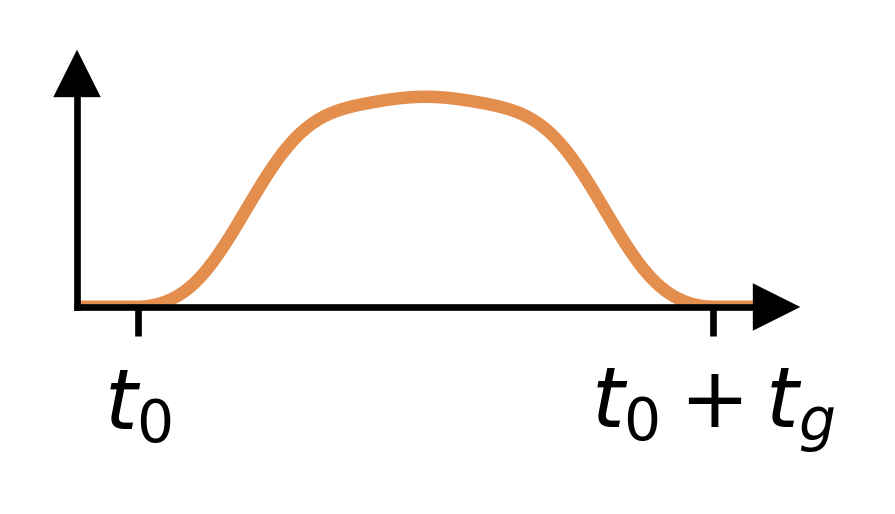

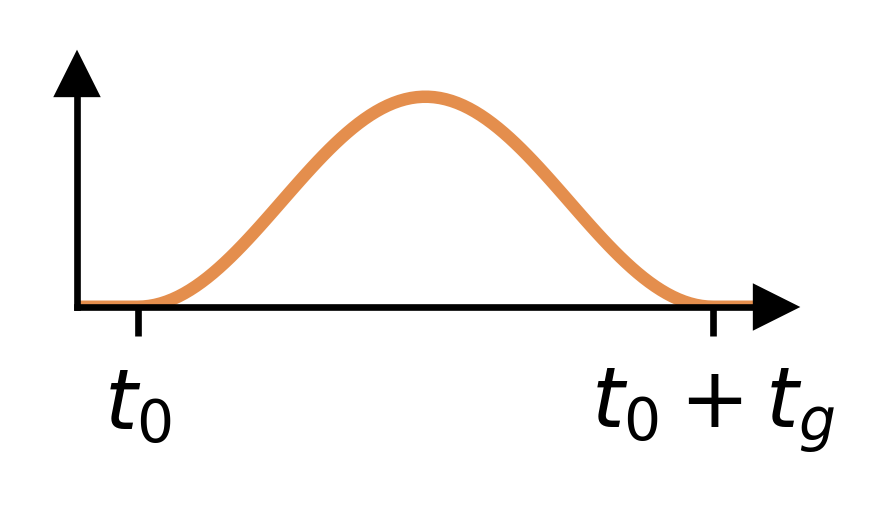

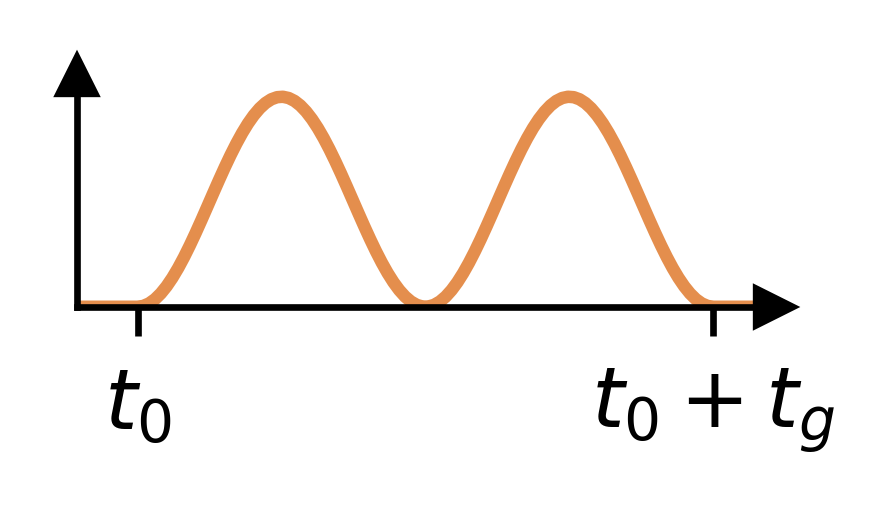

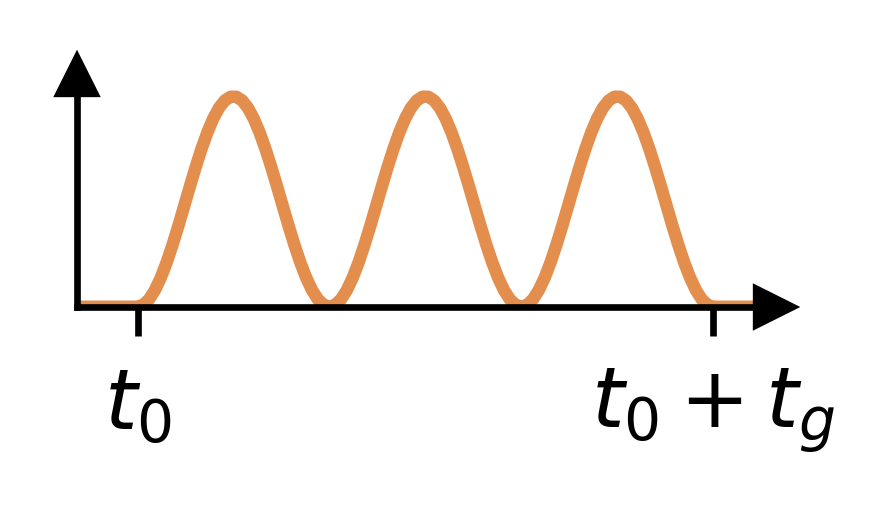

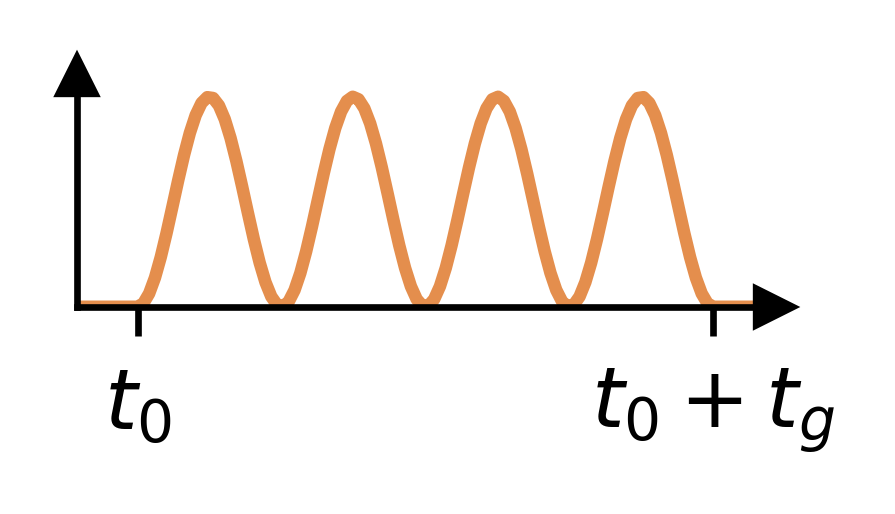

In [57]:
for n in range(5):
    t_0 = 0.5
    #n += 1
    T = np.linspace(t_0, t_g+t_0, 100)
    if n >= 1:
        env = 1-np.cos(2 * np.pi * (n) * (T - t_0) / t_g)
    else:
        env = np.sum([coffs[i] * (1 - np.cos(2 * np.pi * (i + 1) * (T - t_0) / t_g)) for i in range(len(coffs))], axis=0)
    env = [0] + list(env)  + [0]
    T = [0] + list(T) + [t_g+t_0*2]
    env /= np.max(np.abs(env))
    fig, ax = plt.subplots(figsize=(1.5, 0.5), dpi=600)
    ax.plot(T, env, label=f'Component {n}', color='#d95f02', alpha=0.7)
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, t_g+t_0*2)
    #ax.set_xlabel('Time')
    #ax.set_ylabel('Amplitude')
    #ax.set_title(f'Envelope Component {n}')
    #remove y-ticks
    ax.set_yticks([])
    #set x-ticks
    ax.set_xticks([t_0, t_g+t_0])
    ax.set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
    #make cartesian axes
    # Set bottom and left spines as x and y axes of coordinate system
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Draw arrows
    arrow_fmt = dict(markersize=4, color='black', clip_on=False)
    ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
    ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)
    plt.savefig(f'temp/envelope_component_{n}.png')
    plt.show()

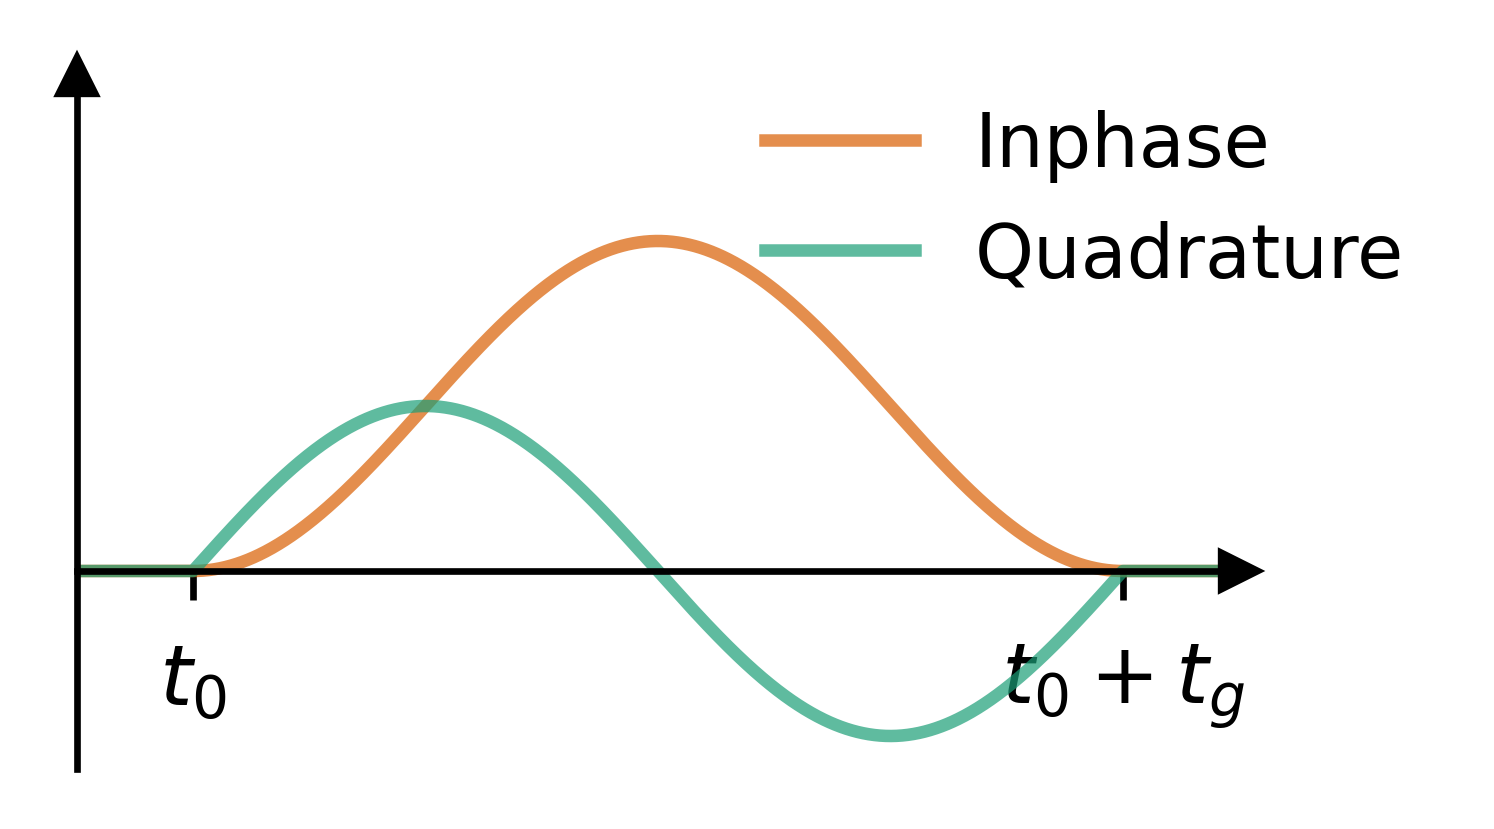

In [25]:
for n in range(1):
    t_0 = 0.1
    n += 1
    T = np.linspace(t_0, t_g+t_0, 1000)
    
    env_I = 1-np.cos(2 * np.pi * (n) * (T - t_0) / t_g)
    env_Q = 2*np.pi*n/t_g*np.sin(2 * np.pi * (n) * (T - t_0) / t_g)
    env_I = [0] + list(env_I)  + [0]
    env_Q = [0] + list(env_Q)  + [0]
    T = [0] + list(T) + [t_g+t_0*2]
    env_I /= np.max(np.abs(env_I))
    env_Q /= np.max(np.abs(env_Q))*2
    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=600)
    ax.plot(T, env_I, label=f'Inphase', color='#d95f02', alpha=0.7)
    ax.plot(T, env_Q, label=f'Quadrature', color='#1b9e77', alpha=0.7)
    ax.set_ylim(-0.6, 1.5)
    ax.set_xlim(0, t_g+t_0*2)
    #ax.set_xlabel('Time')
    #ax.set_ylabel('Amplitude')
    #ax.set_title(f'Envelope Component {n}')
    #remove y-ticks
    ax.set_yticks([])
    #set x-ticks
    ax.set_xticks([t_0, t_g+t_0])
    ax.set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'], position=(0.5, 0.5))  # Center the labels
    ax.xaxis.set_tick_params(pad=5)  # Add some padding to the x-ticks for better visibility
    ax.yaxis.set_tick_params(pad=5)
    #shift the position of the second tick to the right
    

    #make cartesian axes
    # Set bottom and left spines as x and y axes of coordinate system
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Draw arrows
    arrow_fmt = dict(markersize=4, color='black', clip_on=False)
    ax.plot((1), (0), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
    ax.plot((0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)
    plt.legend(
        loc='upper right', fontsize=9, frameon=False, bbox_to_anchor=(1.2, 1.05),
        title_fontsize='9'
    )
    plt.savefig(f'temp/envelope_component_{n}.png')
    plt.show()

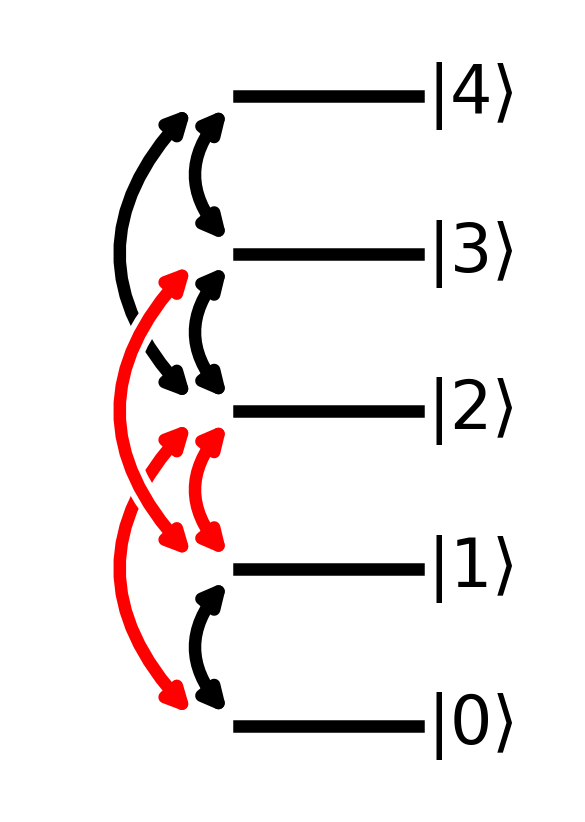

/tmp/ipykernel_1823141/1788536791.py:215: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(f'temp/horizontal_labels_{c}.png')
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 900) to (608, 912) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to horizontal_labels.mp4


<Figure size 640x480 with 0 Axes>

In [116]:
cnt = 0
N = 100
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
for _ in range(N//2):
    fig, ax = plt.subplots(figsize=(1, 1.5), dpi=600)
    #remove axis
    ax.axis('off')
    lower = 0
    lowerl = 0
    for n in range(5):
        plt.plot([0,1],[n,n], color='black')
        plt.annotate(fr'$|{n}\rangle$', xy=(1.05, n), xytext=(1.05, n), fontsize=8, ha='left', va='center')
        #put curved arrows between the lines
        if n >= 1:
            #plt.annotate('', xy=(0.0, n), xytext=(0.0, lower),
            #             arrowprops=dict(arrowstyle='<|-|>', lw=1.5, color='black'),
            #             fontsize=8, ha='center', va='center')
            # Draw a curved arrow from (0.0, lower) to (0.0, n)
            c = 'black'
            if n == 2:
                c = 'red'
            p = patches.FancyArrowPatch((0.0, n), (0.0, lower),
                                        connectionstyle="arc3,rad=0.5",
                                        arrowstyle='<|-|>', lw=1.5, color=c,
                                        mutation_scale=5, shrinkA=2, shrinkB=2)
            ax.add_patch(p)
            if n%2 == 0:
                p = patches.FancyArrowPatch((-0.2, n), (-0.2, lower-1),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color=c,
                                            mutation_scale=5, shrinkA=2, shrinkB=2)
                ax.add_patch(p)
            if (n+1)%2 == 0 and n > 1:
                p = patches.FancyArrowPatch((-0.18, n), (-0.18, lower-1),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=3, color='white',
                                            mutation_scale=1, shrinkA=2, shrinkB=2,
                                            zorder=10)
                ax.add_patch(p)
                p = patches.FancyArrowPatch((-0.2, n), (-0.2, lower-1),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color='red',
                                            mutation_scale=5, shrinkA=2, shrinkB=2,
                                            zorder=15)
                ax.add_patch(p)
            lowerl = lower
            lower = n + 1
        lowerl = lower
        lower = n
    plt.xlim(-1, 1.6)
    plt.savefig(f'temp/horizontal_labels_{cnt}.png')
    if cnt == 0:
        plt.show()
    plt.close(fig)
    plt.clf()
    cnt += 1

for ym in np.linspace(0, 1, N):
    fig, ax = plt.subplots(figsize=(1, 1.5), dpi=600)
    #remove axis
    ax.axis('off')
    lower = 0
    lowerl = 0
    ys = [0, 1, 2, 3, 4]
    ys = [y + ym if y >= 2 else y for y in ys]
    for n in range(5):
        y = ys[n]
        plt.plot([0,1],[y,y], color='black')
        plt.annotate(fr'$|{n}\rangle$', xy=(1.05, y-0.1), xytext=(1.05, y-0.1), fontsize=8, ha='left', va='center')
        """plt.annotate(fr'_', xy=(1.185, y-1+0.4+ym*0.1), xytext=(1.185, y+0.4+ym*0.1), fontsize=8, ha='left', va='center',
                     alpha=ym)"""
        plt.annotate(fr'$eff$', xy=(1.185+0.3, y+0.4+ym*0.1-0.4), xytext=(1.185+0.3, y+0.4+ym*0.1-0.4), fontsize=5, ha='left', va='bottom',
                     alpha=ym)
        #put curved arrows between the lines
        if n >= 1:
            #plt.annotate('', xy=(0.0, n), xytext=(0.0, lower),
            #             arrowprops=dict(arrowstyle='<|-|>', lw=1.5, color='black'),
            #             fontsize=8, ha='center', va='center')
            # Draw a curved arrow from (0.0, lower) to (0.0, n)
            c = 'black'
            a = 1
            if n == 2:
                c = 'red'
                a = 1-ym
            p = patches.FancyArrowPatch((0.0, y), (0.0, ys[n-1]),
                                        connectionstyle="arc3,rad=0.5",
                                        arrowstyle='<|-|>', lw=1.5, color=c,
                                        mutation_scale=5, shrinkA=2, shrinkB=2,
                                        alpha=a)
            ax.add_patch(p)
            if n%2 == 0:
                p = patches.FancyArrowPatch((-0.2, y), (-0.2, ys[n-2]),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color=c,
                                            mutation_scale=5, shrinkA=2, shrinkB=2,
                                            alpha=a)
                ax.add_patch(p)
            if (n+1)%2 == 0 and n > 1:
                p = patches.FancyArrowPatch((-0.2, y), (-0.2, ys[n-2]),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=3, color='white',
                                            mutation_scale=1, shrinkA=2, shrinkB=2,
                                            zorder=10, alpha=1-ym)
                ax.add_patch(p)
                p = patches.FancyArrowPatch((-0.2, y), (-0.2, ys[n-2]),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color='red',
                                            mutation_scale=5, shrinkA=2, shrinkB=2,
                                            zorder=15,alpha=1-ym)
                ax.add_patch(p)
            lowerl = lower
            lower = n + 1
        lowerl = lower
        lower = n
    
    """for n in range(5):
        y = n
        if n >= 2:
            y+=ym
        plt.plot([0,1],[y,y], color='black')
        plt.annotate(fr'$|{n}\rangle$', xy=(1.05, y), xytext=(1.05, y), fontsize=8, ha='left', va='center')
        if n >= 1:
            plt.annotate('', xy=(0.0, n), xytext=(0.0, lower),
                         arrowprops=dict(arrowstyle='<|-|>', lw=1.5, color='black'),
                         fontsize=8, ha='center', va='center')
            lower = n + 1"""
    plt.xlim(-1, 1.6)
    
    plt.savefig(f'temp/horizontal_labels_{cnt}.png')
    #plt.show()
    plt.close(fig)
    plt.clf()
    cnt += 1

for ym in np.linspace(0, 1, N):
    ym = 1
    fig, ax = plt.subplots(figsize=(1, 1.5), dpi=600)
    #remove axis
    ax.axis('off')
    lower = 0
    lowerl = 0
    ys = [0, 1, 2, 3, 4]
    ys = [y + ym if y >= 2 else y for y in ys]
    for n in range(5):
        y = ys[n]
        plt.plot([0,1],[y,y], color='black')
        plt.annotate(fr'$|{n}\rangle$', xy=(1.05, y-0.1), xytext=(1.05, y-0.1), fontsize=8, ha='left', va='center')
        """plt.annotate(fr'_', xy=(1.185, y-1+0.45+ym*0.1), xytext=(1.185, y-1+0.45+ym*0.1), fontsize=8, ha='left', va='center',
                     alpha=1)"""
        """plt.annotate(fr'_', xy=(1.185, y+0.4+ym*0.1), xytext=(1.185, y+0.4+ym*0.1), fontsize=8, ha='left', va='center',
                     alpha=1)
        plt.annotate(fr'_', xy=(1.185, 4.7+0.45+ym*0.1), xytext=(1.185, 4.7+0.45+ym*0.1), fontsize=8, ha='left', va='bottom',
                     alpha=1)"""
        plt.annotate(fr'$eff$', xy=(1.185+0.3, y+0.4+ym*0.1-0.4), xytext=(1.185+0.3, y+0.4+ym*0.1-0.4), fontsize=5, ha='left', va='bottom',
                     alpha=ym)
        #put curved arrows between the lines
        if n >= 1:
            #plt.annotate('', xy=(0.0, n), xytext=(0.0, lower),
            #             arrowprops=dict(arrowstyle='<|-|>', lw=1.5, color='black'),
            #             fontsize=8, ha='center', va='center')
            # Draw a curved arrow from (0.0, lower) to (0.0, n)
            c = 'black'
            a = 1
            if n == 2:
                c = 'red'
                a = 1-ym
            p = patches.FancyArrowPatch((0.0, y), (0.0, ys[n-1]),
                                        connectionstyle="arc3,rad=0.5",
                                        arrowstyle='<|-|>', lw=1.5, color=c,
                                        mutation_scale=5, shrinkA=2, shrinkB=2,
                                        alpha=a)
            ax.add_patch(p)
            if n%2 == 0:
                p = patches.FancyArrowPatch((-0.2, y), (-0.2, ys[n-2]),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color=c,
                                            mutation_scale=5, shrinkA=2, shrinkB=2,
                                            alpha=a)
                ax.add_patch(p)
            if (n+1)%2 == 0 and n > 1:
                p = patches.FancyArrowPatch((-0.2, y), (-0.2, ys[n-2]),
                                            connectionstyle="arc3,rad=0.5",
                                            arrowstyle='<|-|>', lw=1.5, color='red',
                                            mutation_scale=5, shrinkA=2, shrinkB=2,
                                            zorder=15,alpha=1-ym)
                ax.add_patch(p)
            lowerl = lower
            lower = n + 1
        lowerl = lower
        lower = n
    
    """for n in range(5):
        y = n
        if n >= 2:
            y+=ym
        plt.plot([0,1],[y,y], color='black')
        plt.annotate(fr'$|{n}\rangle$', xy=(1.05, y), xytext=(1.05, y), fontsize=8, ha='left', va='center')
        if n >= 1:
            plt.annotate('', xy=(0.0, n), xytext=(0.0, lower),
                         arrowprops=dict(arrowstyle='<|-|>', lw=1.5, color='black'),
                         fontsize=8, ha='center', va='center')
            lower = n + 1"""
    plt.xlim(-1, 1.6)
    plt.savefig(f'temp/horizontal_labels_{cnt}.png')
    #plt.show()
    plt.close(fig)
    plt.clf()
    cnt += 1

import imageio
frames = []
for c in range(cnt):
    img = imageio.imread(f'temp/horizontal_labels_{c}.png')
    frames.append(img)
def frames_to_mp4(frames, output_path, fps=24, codec='libx264', quality=8):
    """
    Convert a list of image frames (numpy arrays) into an MP4 video.
    Parameters:
        frames (list of np.ndarray): List of image frames (all same size and dtype).
        output_path (str): Path to the output MP4 file.
        fps (int): Frames per second for the output video.
        codec (str): Video codec (default 'libx264').
        quality (int): Quality setting (higher is better quality, 0–10 for imageio; default 8).
    """
    if not frames:
        raise ValueError("The frame list is empty.")

    height, width = frames[0].shape[:2]
    for i, frame in enumerate(frames):
        if frame.shape[:2] != (height, width):
            raise ValueError(f"Frame {i} has a different size than the first frame.")

    writer = imageio.get_writer(output_path, fps=fps, codec=codec, quality=quality)

    for frame in frames:
        writer.append_data(frame)

    writer.close()
    print(f"Video saved to {output_path}")
frames_to_mp4(frames, 'horizontal_labels.mp4', fps=N, codec='libx264', quality=8)
import matplotlib.pyplot as plt